In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

from transformers import AutoImageProcessor, SwinForImageClassification

# -------------------------------------------
# CONFIG
# -------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# -------------------------------------------
# TRANSFORMS
# -------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# -------------------------------------------
# LOAD DATA & SPLIT
# -------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, test_val_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_idx, test_idx = next(sss_val.split(np.zeros(len(test_val_idx)), targets[test_val_idx]))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, test_val_idx[val_idx])
test_dataset = Subset(full_dataset, test_val_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {full_dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# -------------------------------------------
# LOAD SWIN FROM HUGGING FACE
# -------------------------------------------
checkpoint = "microsoft/swin-tiny-patch4-window7-224"
processor = AutoImageProcessor.from_pretrained(checkpoint)
model = SwinForImageClassification.from_pretrained(checkpoint, num_labels=NUM_CLASSES)
model.to(DEVICE)

# -------------------------------------------
# LOSS & OPTIMIZER
# -------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# -------------------------------------------
# TRAIN LOOP
# -------------------------------------------
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset)

    # Validation
    model.eval()
    val_correct = 0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images).logits
            val_correct += (outputs.argmax(1) == labels).sum().item()

            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(probs)
            val_targets.extend(labels.cpu().numpy())

    val_acc = val_correct / len(val_dataset)
    val_auc = roc_auc_score(np.eye(NUM_CLASSES)[val_targets], np.array(val_preds), multi_class='ovr')

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

# -------------------------------------------
# TEMPERATURE SCALING (CALIBRATION)
# -------------------------------------------
def temperature_scaling(logits, labels):
    logits = logits.detach().cpu().numpy()
    labels = labels.cpu().numpy()

    def loss_fn(temp):
        temp = temp[0]
        scaled_logits = logits / temp
        exp = np.exp(scaled_logits)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss

    from scipy.optimize import minimize
    res = minimize(loss_fn, x0=[1.0], bounds=[(0.5, 5.0)])
    return res.x[0]

# -------------------------------------------
# TEST EVALUATION
# -------------------------------------------
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images).logits
        all_logits.append(logits)
        all_labels.append(labels)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

# Calibrate
temp = temperature_scaling(all_logits, all_labels)
calibrated_probs = torch.softmax(all_logits / temp, dim=1).cpu().numpy()
test_pred_labels = np.argmax(calibrated_probs, axis=1)
test_targets = all_labels.cpu().numpy()

# Metrics
cm = confusion_matrix(test_targets, test_pred_labels)
report = classification_report(test_targets, test_pred_labels, target_names=full_dataset.classes)

sensitivities = []
specificities = []

for i in range(NUM_CLASSES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

test_auc = roc_auc_score(np.eye(NUM_CLASSES)[test_targets], np.array(calibrated_probs), multi_class='ovr')

print("\n✅ TEST EVALUATION")
print(report)
print(f"Sensitivities: {[round(s, 4) for s in sensitivities]}")
print(f"Specificities: {[round(s, 4) for s in specificities]}")
print(f"AUC-ROC: {test_auc:.4f}")
print(f"Temperature Scaling Factor: {temp:.4f}")

# -------------------------------------------
# PLOT CONFUSION MATRIX
# -------------------------------------------
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# -------------------------------------------
# PLOT ROC CURVE
# -------------------------------------------
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(np.eye(NUM_CLASSES)[test_targets][:, i], calibrated_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-class ROC Curve')
plt.legend()
plt.show()

# -------------------------------------------
# PLOT RELIABILITY DIAGRAM
# -------------------------------------------
probs = calibrated_probs.max(axis=1)
true_labels = (test_pred_labels == test_targets).astype(int)
fraction_of_positives, mean_predicted_value = calibration_curve(true_labels, probs, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Calibrated")
plt.plot([0, 1], [0, 1], "k--")
plt.title('Reliability Diagram')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()


2025-07-05 18:14:49.043615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751739289.276029      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751739289.341116      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Classes: ['Normal_New_Process', 'Osteoporosis_New_Process', 'Ostopenia_New_Process']
Train: 630 | Val: 135 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

RuntimeError: Error(s) in loading state_dict for Linear:
	size mismatch for bias: copying a param with shape torch.Size([1000]) from checkpoint, the shape in current model is torch.Size([3]).

2025-07-05 18:21:07.096174: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751739667.306440      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751739667.372727      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Classes: ['Normal_New_Process', 'Osteoporosis_New_Process', 'Ostopenia_New_Process']
Train: 630 | Val: 135 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/50] Train Loss: 32.5760 | Train Acc: 0.6397 | Val Acc: 0.6963 | Val AUC: 0.8395
Epoch [2/50] Train Loss: 25.6276 | Train Acc: 0.7222 | Val Acc: 0.7185 | Val AUC: 0.8545
Epoch [3/50] Train Loss: 23.2427 | Train Acc: 0.7270 | Val Acc: 0.6519 | Val AUC: 0.8240
Epoch [4/50] Train Loss: 22.8001 | Train Acc: 0.7492 | Val Acc: 0.7333 | Val AUC: 0.8621
Epoch [5/50] Train Loss: 20.2626 | Train Acc: 0.7556 | Val Acc: 0.6741 | Val AUC: 0.8365
Epoch [6/50] Train Loss: 19.3964 | Train Acc: 0.8032 | Val Acc: 0.6148 | Val AUC: 0.7927
Epoch [7/50] Train Loss: 21.0367 | Train Acc: 0.7762 | Val Acc: 0.6889 | Val AUC: 0.8503
Epoch [8/50] Train Loss: 16.0345 | Train Acc: 0.8254 | Val Acc: 0.7111 | Val AUC: 0.8694
Epoch [9/50] Train Loss: 19.0313 | Train Acc: 0.7905 | Val Acc: 0.7333 | Val AUC: 0.8751
Epoch [10/50] Train Loss: 15.7428 | Train Acc: 0.8317 | Val Acc: 0.7333 | Val AUC: 0.8714
Epoch [11/50] Train Loss: 15.9331 | Train Acc: 0.8175 | Val Acc: 0.7407 | Val AUC: 0.8840
Epoch [12/50] Train

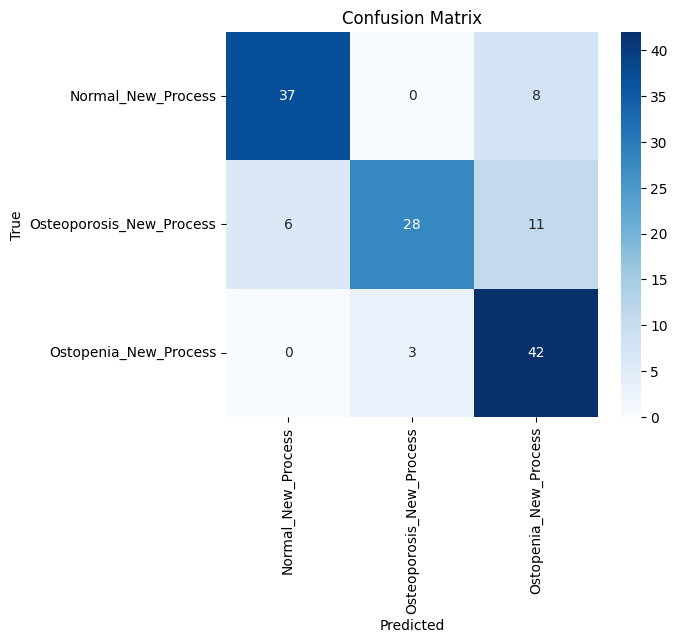

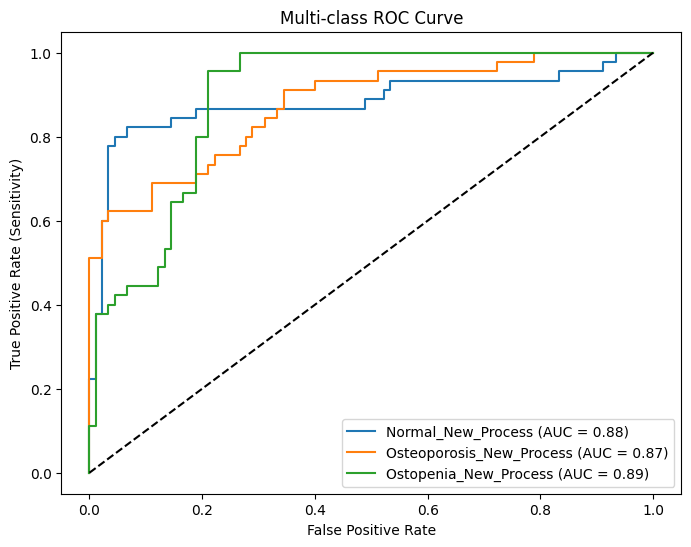

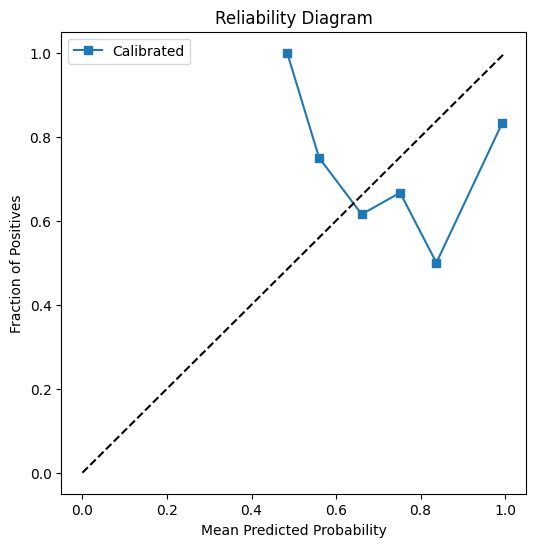

In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification

# -------------------------------------------
# CONFIG
# -------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 50
LR = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# -------------------------------------------
# TRANSFORMS
# -------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# -------------------------------------------
# LOAD DATA & SPLIT
# -------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, test_val_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_idx, test_idx = next(sss_val.split(np.zeros(len(test_val_idx)), targets[test_val_idx]))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, test_val_idx[val_idx])
test_dataset = Subset(full_dataset, test_val_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {full_dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# -------------------------------------------
# LOAD SWIN FROM HUGGING FACE WITH FIX
# -------------------------------------------
checkpoint = "microsoft/swin-tiny-patch4-window7-224"
processor = AutoImageProcessor.from_pretrained(checkpoint)
model = SwinForImageClassification.from_pretrained(
    checkpoint,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True  # ✅ Solves bias mismatch
)
model.to(DEVICE)

# -------------------------------------------
# LOSS & OPTIMIZER
# -------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# -------------------------------------------
# TRAIN LOOP
# -------------------------------------------
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # ✅ Safety resize to match Swin patch size
        images = torch.nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset)

    # Validation
    model.eval()
    val_correct = 0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            images = torch.nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
            outputs = model(images).logits
            val_correct += (outputs.argmax(1) == labels).sum().item()

            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(probs)
            val_targets.extend(labels.cpu().numpy())

    val_acc = val_correct / len(val_dataset)
    val_auc = roc_auc_score(np.eye(NUM_CLASSES)[val_targets], np.array(val_preds), multi_class='ovr')

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

# -------------------------------------------
# TEMPERATURE SCALING (CALIBRATION)
# -------------------------------------------
def temperature_scaling(logits, labels):
    logits = logits.detach().cpu().numpy()
    labels = labels.cpu().numpy()

    def loss_fn(temp):
        temp = temp[0]
        scaled_logits = logits / temp
        exp = np.exp(scaled_logits)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss

    from scipy.optimize import minimize
    res = minimize(loss_fn, x0=[1.0], bounds=[(0.5, 5.0)])
    return res.x[0]

# -------------------------------------------
# TEST EVALUATION
# -------------------------------------------
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        images = torch.nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
        logits = model(images).logits
        all_logits.append(logits)
        all_labels.append(labels)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

# Calibrate
temp = temperature_scaling(all_logits, all_labels)
calibrated_probs = torch.softmax(all_logits / temp, dim=1).cpu().numpy()
test_pred_labels = np.argmax(calibrated_probs, axis=1)
test_targets = all_labels.cpu().numpy()

# Metrics
cm = confusion_matrix(test_targets, test_pred_labels)
report = classification_report(test_targets, test_pred_labels, target_names=full_dataset.classes)

sensitivities = []
specificities = []

for i in range(NUM_CLASSES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

test_auc = roc_auc_score(np.eye(NUM_CLASSES)[test_targets], np.array(calibrated_probs), multi_class='ovr')

print("\n✅ TEST EVALUATION")
print(report)
print(f"Sensitivities: {[round(s, 4) for s in sensitivities]}")
print(f"Specificities: {[round(s, 4) for s in specificities]}")
print(f"AUC-ROC: {test_auc:.4f}")
print(f"Temperature Scaling Factor: {temp:.4f}")

# -------------------------------------------
# PLOT CONFUSION MATRIX
# -------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# -------------------------------------------
# PLOT ROC CURVE
# -------------------------------------------
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(np.eye(NUM_CLASSES)[test_targets][:, i], calibrated_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-class ROC Curve')
plt.legend()
plt.show()

# -------------------------------------------
# PLOT RELIABILITY DIAGRAM
# -------------------------------------------
probs = calibrated_probs.max(axis=1)
true_labels = (test_pred_labels == test_targets).astype(int)
fraction_of_positives, mean_predicted_value = calibration_curve(true_labels, probs, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Calibrated")
plt.plot([0, 1], [0, 1], "k--")
plt.title('Reliability Diagram')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()


2025-07-05 20:17:14.993829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751746635.215513      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751746635.276819      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Classes: ['Normal_New_Process', 'Osteoporosis_New_Process', 'Ostopenia_New_Process']
Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Layers to be fine-tuned:
swin.encoder.layers.3.blocks.0.layernorm_before.weight
swin.encoder.layers.3.blocks.0.layernorm_before.bias
swin.encoder.layers.3.blocks.0.attention.self.relative_position_bias_table
swin.encoder.layers.3.blocks.0.attention.self.query.weight
swin.encoder.layers.3.blocks.0.attention.self.query.bias
swin.encoder.layers.3.blocks.0.attention.self.key.weight
swin.encoder.layers.3.blocks.0.attention.self.key.bias
swin.encoder.layers.3.blocks.0.attention.self.value.weight
swin.encoder.layers.3.blocks.0.attention.self.value.bias
swin.encoder.layers.3.blocks.0.attention.output.dense.weight
swin.encoder.layers.3.blocks.0.attention.output.dense.bias
swin.encoder.layers.3.blocks.0.layernorm_after.weight
swin.encoder.layers.3.blocks.0.layernorm_after.bias
swin.encoder.layers.3.blocks.0.intermediate.dense.weight
swin.encoder.layers.3.blocks.0.intermediate.dense.bias
swin.encoder.layers.3.blocks.0.output.dense.weight
swin.encoder.layers.3.blocks.0.output.dense.bias
swin.enco

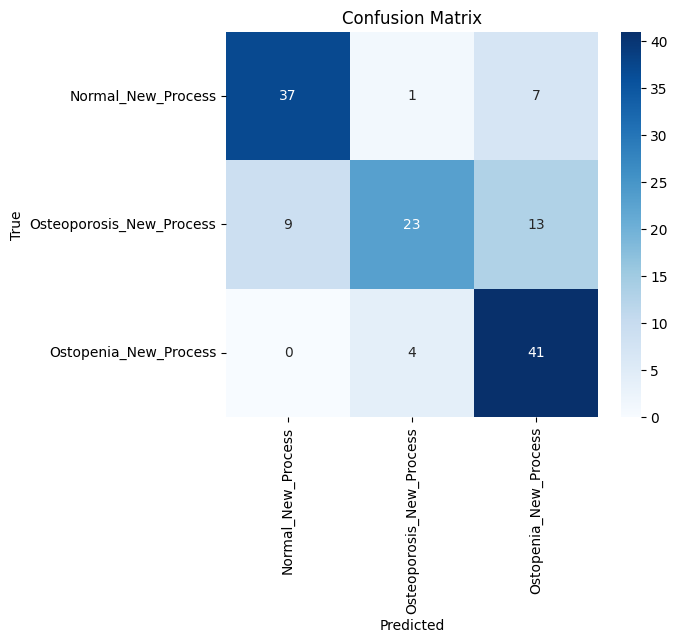

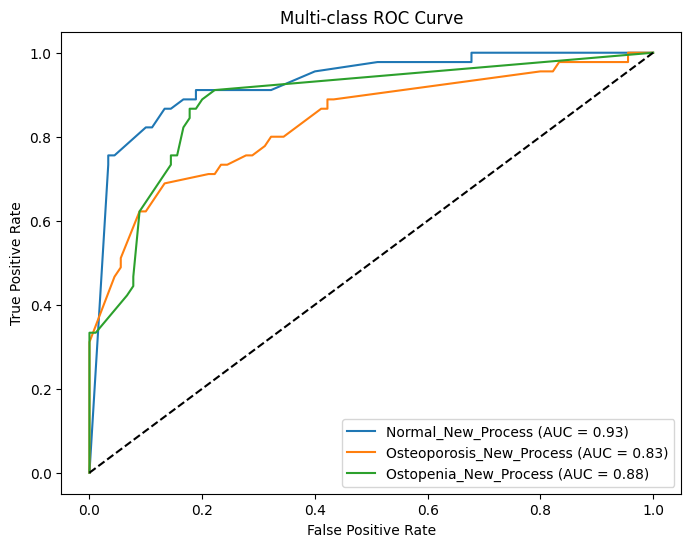

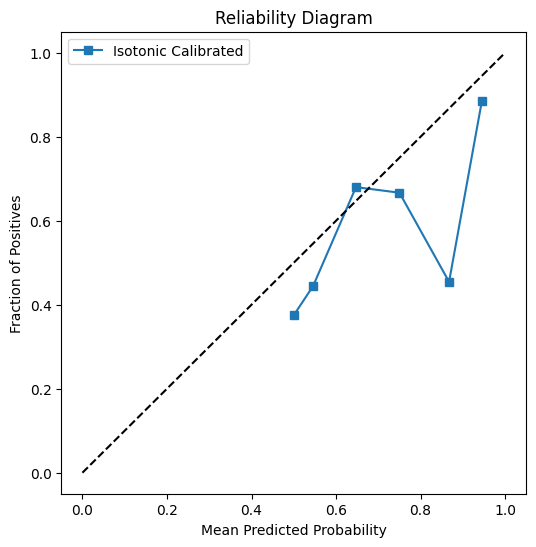

In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc
)
from sklearn.calibration import calibration_curve
from sklearn.calibration import IsotonicRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification

# -------------------------------------------
# CONFIG
# -------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"  # ✅ Update this to your dataset path
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 75
LR = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# -------------------------------------------
# TRANSFORMS
# -------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# -------------------------------------------
# LOAD DATA & SPLIT: Train, Val, Calib, Test
# -------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
targets = np.array(full_dataset.targets)

# Train (70%), rest split into Val (15%) + Calib (15%)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

# Split remaining 30% into Val/Calib/Test
sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

# Split val_calib into Val + Calibration
sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx][val_calib_idx]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {full_dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# -------------------------------------------
# LOAD SWIN WITH PARTIAL FINE-TUNING
# -------------------------------------------
checkpoint = "microsoft/swin-tiny-patch4-window7-224"
processor = AutoImageProcessor.from_pretrained(checkpoint)
model = SwinForImageClassification.from_pretrained(
    checkpoint,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

# ✅ Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# ✅ Unfreeze last Transformer block + layer norm + classifier head
for param in model.swin.encoder.layers[-1].parameters():
    param.requires_grad = True

for param in model.swin.layernorm.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# ✅ Confirm layers
print("\nLayers to be fine-tuned:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

model.to(DEVICE)

# -------------------------------------------
# CLASS-WEIGHTED LOSS
# -------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
class_weights = len(train_targets) / (NUM_CLASSES * class_counts)
print(f"Class Weights: {class_weights}")

weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

# -------------------------------------------
# TRAIN LOOP
# -------------------------------------------
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        images = torch.nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset)

    # Validation
    model.eval()
    val_correct = 0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            images = torch.nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
            outputs = model(images).logits
            val_correct += (outputs.argmax(1) == labels).sum().item()
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(probs)
            val_targets.extend(labels.cpu().numpy())

    val_acc = val_correct / len(val_dataset)
    val_auc = roc_auc_score(np.eye(NUM_CLASSES)[val_targets], np.array(val_preds), multi_class='ovr')

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

# -------------------------------------------
# TEMPERATURE SCALING ON CALIBRATION SET
# -------------------------------------------
def temperature_scaling(logits, labels):
    logits = logits.detach().cpu().numpy()
    labels = labels.cpu().numpy()

    def loss_fn(temp):
        temp = temp[0]
        scaled_logits = logits / temp
        exp = np.exp(scaled_logits)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss

    from scipy.optimize import minimize
    res = minimize(loss_fn, x0=[1.0], bounds=[(0.5, 5.0)])
    return res.x[0]

model.eval()
calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        images = torch.nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
        logits = model(images).logits
        calib_logits.append(logits)
        calib_labels.append(labels)

calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
temp = temperature_scaling(calib_logits, calib_labels)

# -------------------------------------------
# ISOTONIC CALIBRATION
# -------------------------------------------
scaled_probs = torch.softmax(calib_logits / temp, dim=1).cpu().numpy()
iso_models = []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs[:, i], np.eye(NUM_CLASSES)[calib_labels.cpu().numpy()][:, i])
    iso_models.append(ir)

# -------------------------------------------
# TEST EVALUATION WITH ISOTONIC CALIBRATION
# -------------------------------------------
test_logits, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        images = torch.nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
        logits = model(images).logits
        test_logits.append(logits)
        test_labels.append(labels)

test_logits = torch.cat(test_logits)
test_labels = torch.cat(test_labels)

scaled_test_probs = torch.softmax(test_logits / temp, dim=1).cpu().numpy()
iso_test_probs = np.column_stack([
    iso_models[i].predict(scaled_test_probs[:, i]) for i in range(NUM_CLASSES)
])
iso_test_probs /= iso_test_probs.sum(axis=1, keepdims=True)

test_pred_labels = np.argmax(iso_test_probs, axis=1)
test_targets = test_labels.cpu().numpy()

cm = confusion_matrix(test_targets, test_pred_labels)
report = classification_report(test_targets, test_pred_labels, target_names=full_dataset.classes)

sensitivities, specificities = [], []
for i in range(NUM_CLASSES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    sensitivities.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificities.append(TN / (TN + FP) if (TN + FP) > 0 else 0)

test_auc = roc_auc_score(np.eye(NUM_CLASSES)[test_targets], np.array(iso_test_probs), multi_class='ovr')

print("\n✅ TEST EVALUATION (ISOTONIC CALIBRATED)")
print(report)
print(f"Sensitivities: {[round(s, 4) for s in sensitivities]}")
print(f"Specificities: {[round(s, 4) for s in specificities]}")
print(f"AUC-ROC: {test_auc:.4f}")
print(f"Temperature Scaling Factor: {temp:.4f}")

# -------------------------------------------
# VISUALIZE
# -------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(np.eye(NUM_CLASSES)[test_targets][:, i], iso_test_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend()
plt.show()

probs = iso_test_probs.max(axis=1)
true_labels = (test_pred_labels == test_targets).astype(int)
fraction_of_positives, mean_predicted_value = calibration_curve(true_labels, probs, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Isotonic Calibrated")
plt.plot([0, 1], [0, 1], "k--")
plt.title('Reliability Diagram')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()


In [ ]:
# ---------------------------
# IMPORTS & SETUP
# ---------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.calibration import calibration_curve
from sklearn.calibration import IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification

# ---------------------------
# CONFIG
# ---------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 50
LR_BACKBONE = 1e-5
LR_HEAD = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

# ---------------------------
# TRANSFORMS + TTA
# ---------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    test_transform  # identity
]

# ---------------------------
# DATA SPLIT: Train, Val, Calib, Test
# ---------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# ---------------------------
# Initialize Swin & Unfreeze
# ---------------------------
torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

checkpoint = "microsoft/swin-tiny-patch4-window7-224"
processor = AutoImageProcessor.from_pretrained(checkpoint)
model = SwinForImageClassification.from_pretrained(
    checkpoint,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

for param in model.parameters():
    param.requires_grad = False

# -----------------------------------------
# Partial unfreeze: last 2–3 encoder blocks, layernorm, classifier
# -----------------------------------------
for name, param in model.named_parameters():
    if ("encoder.layers.9" in name or "encoder.layers.10" in name or "encoder.layers.11" in name):
        param.requires_grad = True
    elif "classifier" in name or "layernorm" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Safety check:
num_grad = sum(p.requires_grad for p in model.parameters())
print(f"Trainable params: {num_grad}")
assert num_grad > 0, "ERROR: No parameters are trainable!"


# ✅ Non-overlapping param groups
backbone_params, classifier_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if ("encoder.layers.9" in name or "encoder.layers.10" in name or "encoder.layers.11" in name):
        backbone_params.append(param)
    elif "classifier" in name or "layernorm" in name:
        classifier_params.append(param)

print(f"Backbone params: {len(backbone_params)} | Classifier params: {len(classifier_params)}")

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': classifier_params, 'lr': LR_HEAD}
])

model = model.to(DEVICE)

# ---------------------------
# Label Smoothing
# ---------------------------
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, x, target):
        logprobs = torch.nn.functional.log_softmax(x, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

criterion = LabelSmoothingCrossEntropy()

# ---------------------------
# TRAIN LOOP
# ---------------------------
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f}")

# ---------------------------
# Vector Scaling
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images).logits
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)

vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")

# ---------------------------
# Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")

# ---------------------------
# TTA Predictions
# ---------------------------
model.eval()
tta_probs, test_labels_list = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cpu()
        batch_probs = []
        for tta_transform in tta_transforms:
            tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images])
            tta_images = tta_images.to(DEVICE)
            outputs = model(tta_images).logits
            scaled = outputs.cpu().numpy() / vector_temps
            exp = np.exp(scaled)
            probs = exp / np.sum(exp, axis=1, keepdims=True)
            batch_probs.append(probs)
        avg_probs = np.mean(batch_probs, axis=0)
        tta_probs.append(avg_probs)
        test_labels_list.append(labels)

probs = np.vstack(tta_probs)
test_labels = torch.cat(test_labels_list).numpy()

# Apply Isotonic & Beta
iso_probs = np.column_stack([iso_models[i].predict(probs[:, i]) for i in range(NUM_CLASSES)])
iso_probs /= iso_probs.sum(axis=1, keepdims=True)
beta_probs = np.column_stack([betainc(beta_params[i][0], beta_params[i][1], probs[:, i]) for i in range(NUM_CLASSES)])
beta_probs /= beta_probs.sum(axis=1, keepdims=True)

# Manual Conformal sets
pred_sets = []
for p in probs:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

# ---------------------------
# Evaluate Functions
# ---------------------------
def evaluate(probs, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"Underlying softmax AUC: {auc:.4f}")

# ---------------------------
# Final Reports
# ---------------------------
evaluate(iso_probs, "Isotonic Calibrated")
evaluate(beta_probs, "Beta Calibrated")
evaluate_conformal(pred_sets, "Manual Conformal")


2025-07-06 10:09:51.544598: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751796591.782197      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751796591.850491      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 52
Backbone params: 0 | Classifier params: 52
Epoch [1/50] Train Loss: 41.4007 | Train Acc: 0.5048
Epoch [2/50] Train Loss: 37.3550 | Train Acc: 0.6698


In [ ]:
# ---------------------------
# IMPORTS & SETUP
# ---------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.calibration import IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification

# ---------------------------
# CONFIG
# ---------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# ---------------------------
# TRANSFORMS + TTA
# ---------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    test_transform  # identity
]

# ---------------------------
# DATA SPLIT: Train, Val, Calib, Test
# ---------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# ---------------------------
# SE-Block + Swin Definition
# ---------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# Wrap Swin with SE-Block
class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)

    def forward(self, x):
        outputs = self.swin(x)  # returns BaseModelOutputWithPooling
        features = outputs.last_hidden_state  # (B, N, C)

        # Reshape tokens to pseudo spatial for SEBlock
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)  # (B,C,N,1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)  # (B,N,C)

        # Get pooler_output (norm + mean)
        pooled = features.mean(dim=1)  # you can use outputs.pooler_output too
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits



# ---------------------------
# Load Swin + SE
# ---------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True  
)
model = SwinWithSE(base_model).to(DEVICE)

# ---------------------------
# Unfreeze only classifier
# ---------------------------
for name, param in model.named_parameters():
    if "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# ---------------------------
# Class-Balanced Loss
# ---------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / np.array(effective_num)
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# ---------------------------
# Optimizer with Weight Decay
# ---------------------------
classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]
optimizer = torch.optim.AdamW(classifier_params, lr=LR, weight_decay=WEIGHT_DECAY)

# ---------------------------
# Train loop
# ---------------------------
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f}")

# ---------------------------
# Vector Scaling
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

# Calibration logits
calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)

vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")

# ---------------------------
# Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")

# ---------------------------
# TTA Predictions
# ---------------------------
model.eval()
tta_probs, test_labels_list = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.cpu()
        batch_probs = []
        for tta_transform in tta_transforms:
            tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images])
            tta_images = tta_images.to(DEVICE)
            outputs = model(tta_images)
            scaled = outputs.cpu().numpy() / vector_temps
            exp = np.exp(scaled)
            probs = exp / np.sum(exp, axis=1, keepdims=True)
            batch_probs.append(probs)
        avg_probs = np.mean(batch_probs, axis=0)
        tta_probs.append(avg_probs)
        test_labels_list.append(labels)

probs = np.vstack(tta_probs)
test_labels = torch.cat(test_labels_list).numpy()

iso_probs = np.column_stack([iso_models[i].predict(probs[:, i]) for i in range(NUM_CLASSES)])
iso_probs /= iso_probs.sum(axis=1, keepdims=True)
beta_probs = np.column_stack([betainc(beta_params[i][0], beta_params[i][1], probs[:, i]) for i in range(NUM_CLASSES)])
beta_probs /= beta_probs.sum(axis=1, keepdims=True)

pred_sets = []
for p in probs:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

# ---------------------------
# Evaluate Functions
# ---------------------------
def evaluate(probs, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"Underlying softmax AUC: {auc:.4f}")

# ---------------------------
# Final Reports
# ---------------------------
evaluate(iso_probs, "Isotonic Calibrated")
evaluate(beta_probs, "Beta Calibrated")
evaluate_conformal(pred_sets, "Manual Conformal")


Train: 630 | Val: 67 | Calib: 68 | Test: 135


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/50] Loss: 42.6525 | Train Acc: 0.4270
Epoch [2/50] Loss: 40.2811 | Train Acc: 0.6063
Epoch [3/50] Loss: 38.5973 | Train Acc: 0.6540
Epoch [4/50] Loss: 37.5199 | Train Acc: 0.6651


2025-07-06 14:05:29.015829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751810729.200042      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751810729.252094      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/60] Train Loss: 42.6525 | Train Acc: 0.4270 | Val Loss: 5.1203 | Val Acc: 0.5970
Epoch [2/60] Train Loss: 40.1300 | Train Acc: 0.6270 | Val Loss: 4.8912 | Val Acc: 0.6119
Epoch [3/60] Train Loss: 38.5678 | Train Acc: 0.6460 | Val Loss: 4.7635 | Val Acc: 0.6418
Epoch [4/60] Train Loss: 37.0794 | Train Acc: 0.6492 | Val Loss: 4.5874 | Val Acc: 0.6567
Epoch [5/60] Train Loss: 36.2924 | Train Acc: 0.6667 | Val Loss: 4.3836 | Val Acc: 0.7015
Epoch [6/60] Train Loss: 34.9870 | Train Acc: 0.6841 | Val Loss: 4.2364 | Val Acc: 0.7015
Epoch [7/60] Train Loss: 34.5469 | Train Acc: 0.6825 | Val Loss: 4.1849 | Val Acc: 0.6866
Epoch [8/60] Train Loss: 33.7205 | Train Acc: 0.6778 | Val Loss: 3.9590 | Val Acc: 0.6866
Epoch [9/60] Train Loss: 33.4837 | Train Acc: 0.6921 | Val Loss: 4.0389 | Val Acc: 0.7015
Epoch [10/60] Train Loss: 33.1202 | Train Acc: 0.6825 | Val Loss: 3.8869 | Val Acc: 0.7313
Epoch [11/60] Train Loss: 32.4628 | Train Acc: 0.6825 | Val Loss: 3.8294 | Val Acc: 0.7015
Epoch [1

/tmp/ipykernel_35/977734892.py:239: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()



✅ Before TTA - Isotonic Calibrated RESULTS
AUC: 0.8122
                          precision    recall  f1-score   support

      Normal_New_Process       0.85      0.62      0.72        45
Osteoporosis_New_Process       0.66      0.69      0.67        45
   Ostopenia_New_Process       0.65      0.80      0.72        45

                accuracy                           0.70       135
               macro avg       0.72      0.70      0.70       135
            weighted avg       0.72      0.70      0.70       135

ECE: 0.1356 | MCE: 0.5129


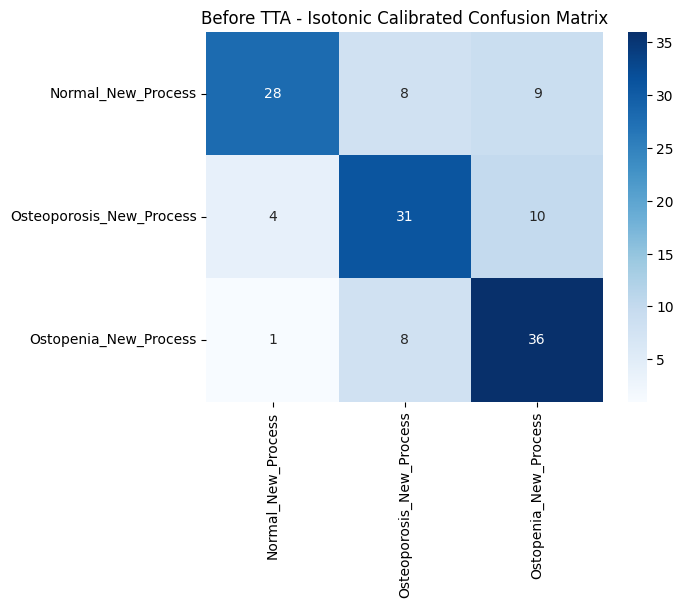


✅ Before TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8889
Avg Set Size: 1.70

✅ After TTA - Isotonic Calibrated RESULTS
AUC: 0.8009
                          precision    recall  f1-score   support

      Normal_New_Process       0.84      0.58      0.68        45
Osteoporosis_New_Process       0.71      0.64      0.67        45
   Ostopenia_New_Process       0.62      0.87      0.72        45

                accuracy                           0.70       135
               macro avg       0.72      0.70      0.69       135
            weighted avg       0.72      0.70      0.69       135

ECE: 0.1090 | MCE: 0.4573


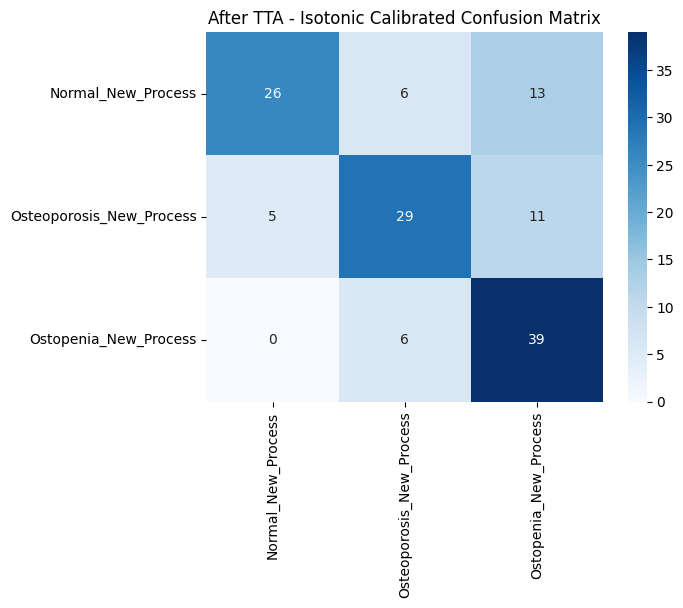


✅ After TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8667
Avg Set Size: 1.68


In [1]:
# ---------------------------
# IMPORTS & SETUP
# ---------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification

# ---------------------------
# CONFIG
# ---------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 60
LR = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# ---------------------------
# TRANSFORMS + TTA
# ---------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    test_transform
]

# ---------------------------
# DATA SPLIT: Train, Val, Calib, Test
# ---------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# ---------------------------
# SE-Block + Swin Definition
# ---------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)

    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# ---------------------------
# Load & wrap model
# ---------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

for name, param in model.named_parameters():
    if "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# ---------------------------
# Class-Balanced Loss + Optimizer
# ---------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]
optimizer = torch.optim.AdamW(classifier_params, lr=LR, weight_decay=WEIGHT_DECAY)

# ---------------------------
# TRAIN + VALIDATION LOOP
# ---------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)

    # Validation loop
    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"Best Val Accuracy: {best_val_acc:.4f}")
# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")

# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")

# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels

# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)

# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")


In [1]:
from transformers import SwinForImageClassification

# Load model
model = SwinForImageClassification.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

# Print all named parameters
for name, param in model.named_parameters():
    print(name)


2025-07-06 17:11:39.748679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751821899.966130      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751821900.033309      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

swin.embeddings.patch_embeddings.projection.weight
swin.embeddings.patch_embeddings.projection.bias
swin.embeddings.norm.weight
swin.embeddings.norm.bias
swin.encoder.layers.0.blocks.0.layernorm_before.weight
swin.encoder.layers.0.blocks.0.layernorm_before.bias
swin.encoder.layers.0.blocks.0.attention.self.relative_position_bias_table
swin.encoder.layers.0.blocks.0.attention.self.query.weight
swin.encoder.layers.0.blocks.0.attention.self.query.bias
swin.encoder.layers.0.blocks.0.attention.self.key.weight
swin.encoder.layers.0.blocks.0.attention.self.key.bias
swin.encoder.layers.0.blocks.0.attention.self.value.weight
swin.encoder.layers.0.blocks.0.attention.self.value.bias
swin.encoder.layers.0.blocks.0.attention.output.dense.weight
swin.encoder.layers.0.blocks.0.attention.output.dense.bias
swin.encoder.layers.0.blocks.0.layernorm_after.weight
swin.encoder.layers.0.blocks.0.layernorm_after.bias
swin.encoder.layers.0.blocks.0.intermediate.dense.weight
swin.encoder.layers.0.blocks.0.inter

2025-07-06 17:58:03.654907: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751824684.068412      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751824684.176539      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/75] Train Loss: 41.4871 | Val Loss: 4.8436 | Train Acc: 0.4889 | Val Acc: 0.6716
Epoch [2/75] Train Loss: 36.6627 | Val Loss: 4.3732 | Train Acc: 0.6857 | Val Acc: 0.6866
Epoch [3/75] Train Loss: 33.2797 | Val Loss: 4.0395 | Train Acc: 0.6714 | Val Acc: 0.6866
Epoch [4/75] Train Loss: 30.7729 | Val Loss: 3.6607 | Train Acc: 0.6921 | Val Acc: 0.7164
Epoch [5/75] Train Loss: 29.3870 | Val Loss: 3.5681 | Train Acc: 0.6825 | Val Acc: 0.7313
Epoch [6/75] Train Loss: 27.5559 | Val Loss: 3.3599 | Train Acc: 0.7063 | Val Acc: 0.7164
Epoch [7/75] Train Loss: 27.2382 | Val Loss: 3.1923 | Train Acc: 0.6984 | Val Acc: 0.7015
Epoch [8/75] Train Loss: 26.0768 | Val Loss: 3.1543 | Train Acc: 0.7079 | Val Acc: 0.7164
Epoch [9/75] Train Loss: 26.0250 | Val Loss: 3.1496 | Train Acc: 0.7238 | Val Acc: 0.7015
Epoch [10/75] Train Loss: 25.7680 | Val Loss: 3.0460 | Train Acc: 0.7111 | Val Acc: 0.7313
Epoch [11/75] Train Loss: 25.4149 | Val Loss: 2.8618 | Train Acc: 0.7111 | Val Acc: 0.7015
Epoch [1

/tmp/ipykernel_35/613183369.py:241: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()



✅ Before TTA - Isotonic Calibrated RESULTS
AUC: 0.8678
                          precision    recall  f1-score   support

      Normal_New_Process       0.82      0.62      0.71        45
Osteoporosis_New_Process       0.69      0.60      0.64        45
   Ostopenia_New_Process       0.65      0.89      0.75        45

                accuracy                           0.70       135
               macro avg       0.72      0.70      0.70       135
            weighted avg       0.72      0.70      0.70       135

ECE: 0.1061 | MCE: 0.2023


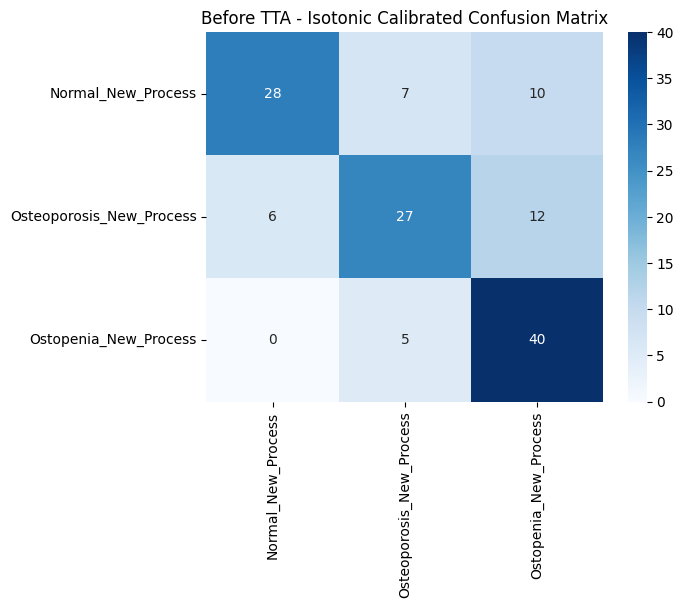


✅ Before TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8667
Avg Set Size: 1.41

✅ After TTA - Isotonic Calibrated RESULTS
AUC: 0.8480
                          precision    recall  f1-score   support

      Normal_New_Process       0.79      0.69      0.74        45
Osteoporosis_New_Process       0.74      0.62      0.67        45
   Ostopenia_New_Process       0.64      0.82      0.72        45

                accuracy                           0.71       135
               macro avg       0.72      0.71      0.71       135
            weighted avg       0.72      0.71      0.71       135

ECE: 0.1540 | MCE: 0.6495


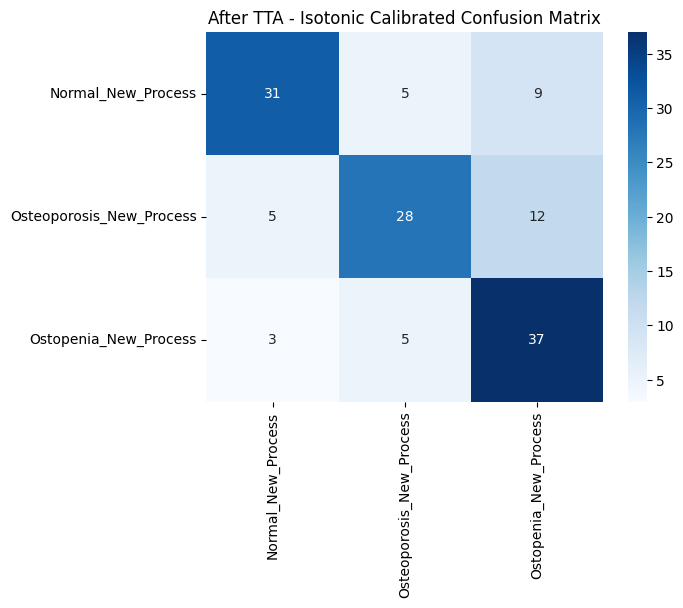


✅ After TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8815
Avg Set Size: 1.49


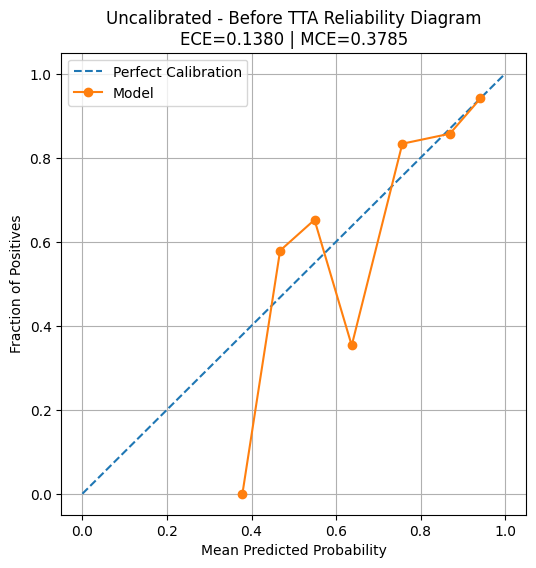

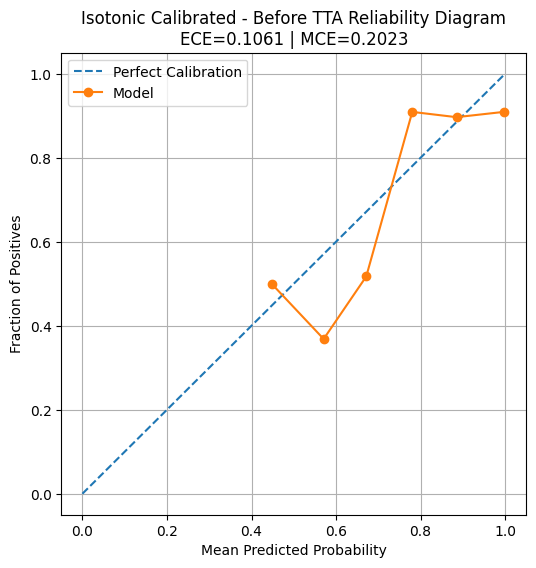

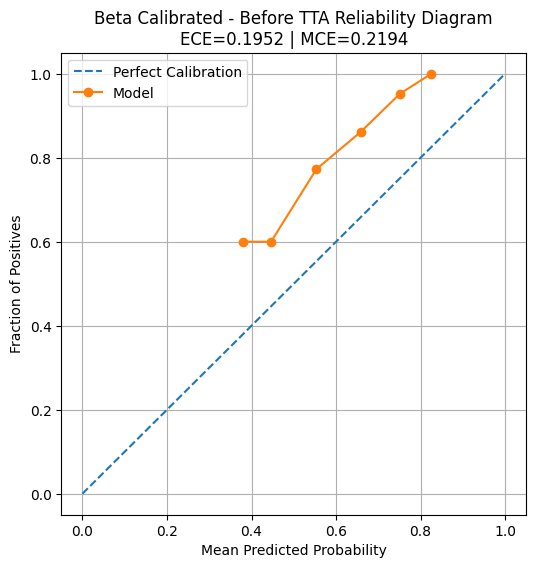

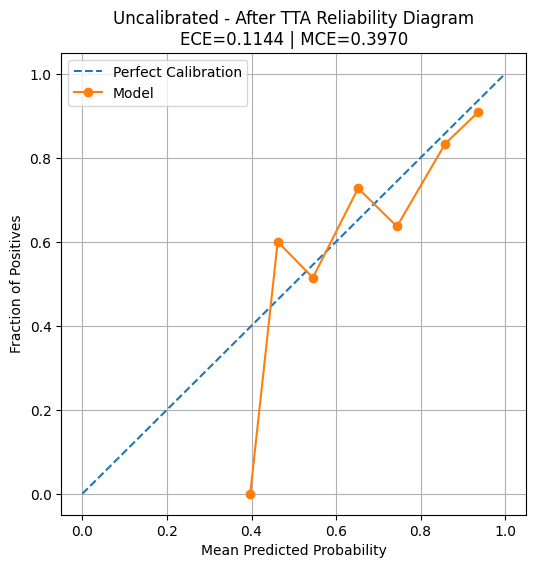

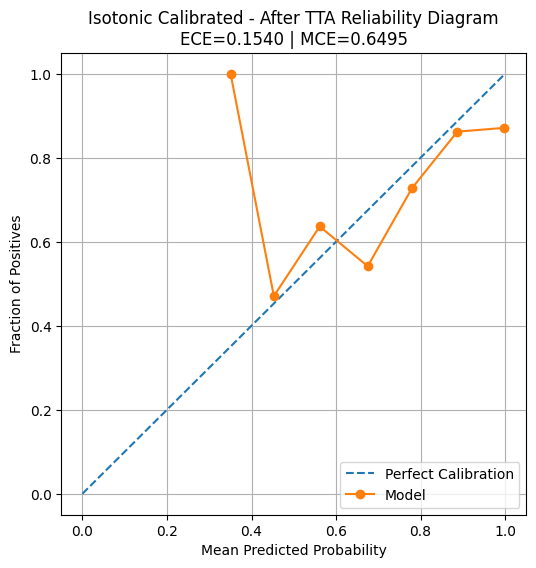

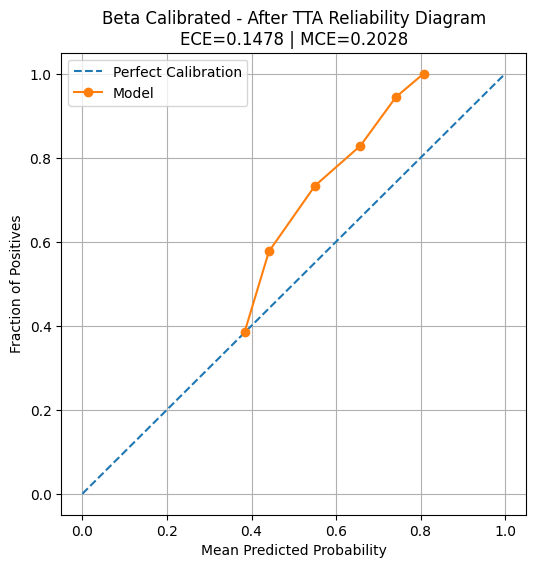


✅ Before TTA - Beta Calibrated RESULTS
AUC: 0.8697
                          precision    recall  f1-score   support

      Normal_New_Process       0.86      0.67      0.75        45
Osteoporosis_New_Process       0.82      0.60      0.69        45
   Ostopenia_New_Process       0.66      0.98      0.79        45

                accuracy                           0.75       135
               macro avg       0.78      0.75      0.74       135
            weighted avg       0.78      0.75      0.74       135

ECE: 0.1952 | MCE: 0.2194


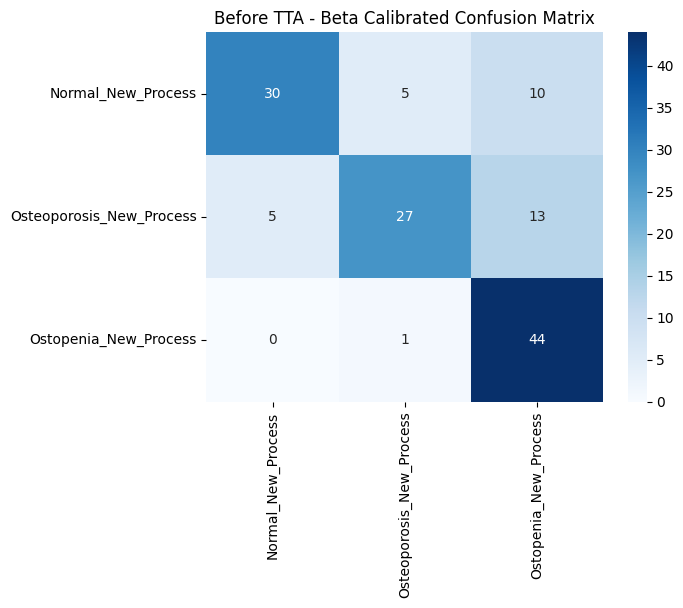


✅ After TTA - Beta Calibrated RESULTS
AUC: 0.8529
                          precision    recall  f1-score   support

      Normal_New_Process       0.81      0.64      0.72        45
Osteoporosis_New_Process       0.71      0.56      0.63        45
   Ostopenia_New_Process       0.62      0.89      0.73        45

                accuracy                           0.70       135
               macro avg       0.71      0.70      0.69       135
            weighted avg       0.71      0.70      0.69       135

ECE: 0.1478 | MCE: 0.2028


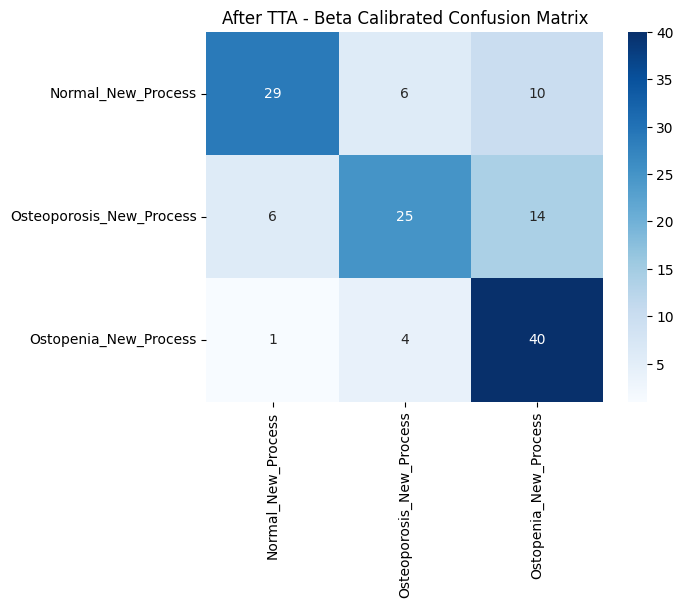

TraceError: symbolically traced variables cannot be used as inputs to control flow

In [1]:
# IMPORTS & SETUP
# --------------------------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification
import cv2

# --------------------------------------------
# CONFIG
# --------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 75
LR_BACKBONE = 1e-5
LR_HEAD = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# --------------------------------------------
# TRANSFORMS & TTA
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
]

# --------------------------------------------
# DATA SPLIT
# --------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# --------------------------------------------
# SEBlock + Swin Definition
# --------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)
    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# --------------------------------------------
# LOAD & WRAP MODEL
# --------------------------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

# ✅ Unfreeze final block
for name, param in model.named_parameters():
    if name.startswith("swin.encoder.layers.3.blocks.1") or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --------------------------------------------
# Class Balanced Loss + Optimizer
# --------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

backbone_params = [p for n, p in model.named_parameters() if "swin.encoder.layers.3.blocks.1" in n and p.requires_grad]
classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": classifier_params, "lr": LR_HEAD}
], weight_decay=WEIGHT_DECAY)

# --------------------------------------------
# Training Loop + Validation
# --------------------------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)

    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")
# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")
# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")
# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels
# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)
# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")
# ---------------------------
# Reliability Diagram Helper
# ---------------------------
def plot_reliability(true_labels, probs, name):
    preds = np.argmax(probs, axis=1)
    true_labels_bin = (preds == true_labels).astype(int)
    probs_max = probs.max(axis=1)

    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------
# BETA Calibrated Probabilities
# ---------------------------
beta_probs_raw = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_raw[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_raw /= beta_probs_raw.sum(axis=1, keepdims=True)

beta_probs_tta = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_tta[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_tta /= beta_probs_tta.sum(axis=1, keepdims=True)

# ---------------------------
# RELIABILITY PLOTS
# ---------------------------
plot_reliability(test_labels, probs_raw, "Uncalibrated - Before TTA")
plot_reliability(test_labels, iso_probs_raw, "Isotonic Calibrated - Before TTA")
plot_reliability(test_labels, beta_probs_raw, "Beta Calibrated - Before TTA")

plot_reliability(test_labels, probs_tta, "Uncalibrated - After TTA")
plot_reliability(test_labels, iso_probs_tta, "Isotonic Calibrated - After TTA")
plot_reliability(test_labels, beta_probs_tta, "Beta Calibrated - After TTA")

# ---------------------------
# Evaluate Beta
# ---------------------------
evaluate(beta_probs_raw, test_labels, "Before TTA - Beta Calibrated")
evaluate(beta_probs_tta, test_labels, "After TTA - Beta Calibrated")

# ---------------------------
# 🔍 GRAD CAM Example
# ---------------------------
def gradcam_visualization(input_image, target_class=None):
    from torchvision.models.feature_extraction import create_feature_extractor

    extractor = create_feature_extractor(model.swin, return_nodes={"encoder.layers.3.blocks.1.output.dense": "feat"})
    model.eval()
    input_image = input_image.unsqueeze(0).to(DEVICE).requires_grad_()
    out = extractor(input_image)
    feature_map = out["feat"]  # Shape: (1, N, C)

    logits = model(input_image)
    class_idx = target_class if target_class is not None else logits.argmax().item()
    logits[0, class_idx].backward()

    grad = input_image.grad.data
    weights = grad.mean(dim=[2, 3], keepdim=True)
    cam = (weights * feature_map).sum(dim=1).squeeze().cpu().detach().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = cam / cam.max()

    plt.imshow(input_image.squeeze().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
    plt.imshow(cam, cmap="jet", alpha=0.5)
    plt.title(f"GradCAM for class {class_idx}")
    plt.axis("off")
    plt.show()

# ---------------------------
# ✅ Example Usage of GradCAM
# ---------------------------
example_img, _ = next(iter(test_loader))
gradcam_visualization(example_img[0])



2025-07-07 18:47:13.351613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751914033.795501      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751914033.901884      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/75] Train Loss: 41.4871 | Val Loss: 4.8436 | Train Acc: 0.4889 | Val Acc: 0.6716
Epoch [2/75] Train Loss: 36.6627 | Val Loss: 4.3732 | Train Acc: 0.6857 | Val Acc: 0.6866
Epoch [3/75] Train Loss: 33.2797 | Val Loss: 4.0395 | Train Acc: 0.6714 | Val Acc: 0.6866
Epoch [4/75] Train Loss: 30.7729 | Val Loss: 3.6607 | Train Acc: 0.6921 | Val Acc: 0.7164
Epoch [5/75] Train Loss: 29.3870 | Val Loss: 3.5681 | Train Acc: 0.6825 | Val Acc: 0.7313
Epoch [6/75] Train Loss: 27.5559 | Val Loss: 3.3599 | Train Acc: 0.7063 | Val Acc: 0.7164
Epoch [7/75] Train Loss: 27.2382 | Val Loss: 3.1923 | Train Acc: 0.6984 | Val Acc: 0.7015
Epoch [8/75] Train Loss: 26.0768 | Val Loss: 3.1543 | Train Acc: 0.7079 | Val Acc: 0.7164
Epoch [9/75] Train Loss: 26.0250 | Val Loss: 3.1496 | Train Acc: 0.7238 | Val Acc: 0.7015
Epoch [10/75] Train Loss: 25.7680 | Val Loss: 3.0460 | Train Acc: 0.7111 | Val Acc: 0.7313
Epoch [11/75] Train Loss: 25.4149 | Val Loss: 2.8618 | Train Acc: 0.7111 | Val Acc: 0.7015
Epoch [1

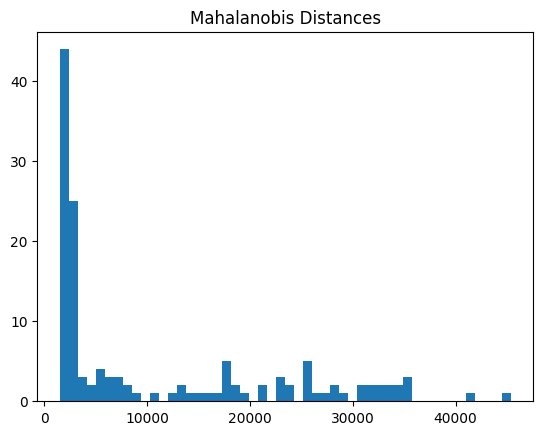

✅ Best Val Accuracy: 0.8060


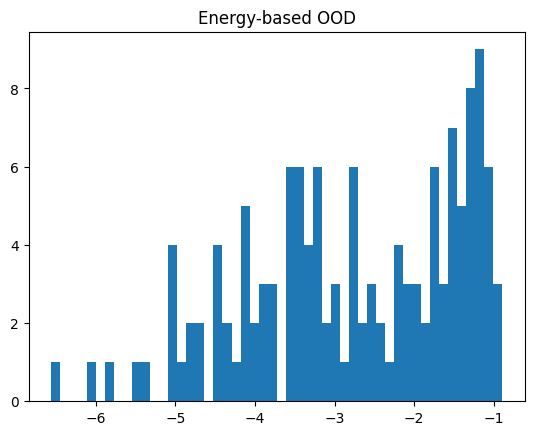

/tmp/ipykernel_35/886863551.py:297: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  grad = torch.sign(x.grad.data)


AttributeError: 'NoneType' object has no attribute 'data'

In [1]:
# IMPORTS & SETUP
# --------------------------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification
import cv2

# --------------------------------------------
# CONFIG
# --------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 75
LR_BACKBONE = 1e-5
LR_HEAD = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# --------------------------------------------
# TRANSFORMS & TTA
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
]

# --------------------------------------------
# DATA SPLIT
# --------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# --------------------------------------------
# SEBlock + Swin Definition
# --------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)
    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# --------------------------------------------
# LOAD & WRAP MODEL
# --------------------------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

# ✅ Unfreeze final block
for name, param in model.named_parameters():
    if name.startswith("swin.encoder.layers.3.blocks.1") or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --------------------------------------------
# Class Balanced Loss + Optimizer
# --------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

backbone_params = [p for n, p in model.named_parameters() if "swin.encoder.layers.3.blocks.1" in n and p.requires_grad]
classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": classifier_params, "lr": LR_HEAD}
], weight_decay=WEIGHT_DECAY)

# --------------------------------------------
# Training Loop + Validation
# --------------------------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)

    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# 1️⃣ Extract penultimate layer embeddings
def get_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE)
            outputs = model.swin(images)
            # Swin's final transformer block output
            feat = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(feat.cpu().numpy())
            labels.extend(target.numpy())
    return np.vstack(embeddings), np.array(labels)

# Compute class means and covariances
train_embeds, train_labels = get_embeddings(train_dataset)
class_means, class_covs_inv = [], []
for cls in range(NUM_CLASSES):
    cls_feats = train_embeds[train_labels == cls]
    mu = np.mean(cls_feats, axis=0)
    cov = np.cov(cls_feats, rowvar=False) + np.eye(cls_feats.shape[1]) * 1e-6  # Stabilize
    cov_inv = inv(cov)
    class_means.append(mu)
    class_covs_inv.append(cov_inv)

# Compute Mahalanobis distance for test set
test_embeds, test_labels = get_embeddings(test_dataset)
mahal_distances = []
for embed in test_embeds:
    dists = [mahalanobis(embed, mu, cov_inv)
             for mu, cov_inv in zip(class_means, class_covs_inv)]
    mahal_distances.append(min(dists))  # Take min distance over classes

plt.hist(mahal_distances, bins=50)
plt.title("Mahalanobis Distances")
plt.show()
# ------------------------------------------------------------
# ✅ ADDITIONAL IMPORTS FOR OOD
# ------------------------------------------------------------
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from scipy.special import logsumexp
import pandas as pd

# ------------------------------------------------------------
# ✅ AFTER TRAINING AND LOADING BEST MODEL
# ------------------------------------------------------------
model.load_state_dict(best_model_state)
model.eval()
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")


# ------------------------------------------------------------
# ✅ 2️⃣ Energy-based OOD Scores
# ------------------------------------------------------------
def compute_energy(logits, T=1.0):
    logits_np = logits.cpu().numpy()
    return -T * logsumexp(logits_np / T, axis=1)

energy_scores = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        e = compute_energy(logits)
        energy_scores.extend(e)

plt.hist(energy_scores, bins=50)
plt.title("Energy-based OOD")
plt.show()

# ------------------------------------------------------------
# ✅ 3️⃣ ODIN Detector
# ------------------------------------------------------------
def odin_score(x, T=1000, eps=0.0014):
    x = x.clone().detach().requires_grad_(True).to(DEVICE)
    logits = model(x) / T
    probs = torch.softmax(logits, dim=1)
    max_probs, _ = torch.max(probs, dim=1)
    loss = -torch.mean(torch.log(max_probs))
    loss.backward()
    grad = torch.sign(x.grad.data)
    x_perturbed = x - eps * grad
    logits_p = model(x_perturbed) / T
    probs_p = torch.softmax(logits_p, dim=1)
    max_probs_p, _ = torch.max(probs_p, dim=1)
    return max_probs_p.cpu().numpy()

odin_scores = []
for images, _ in test_loader:
    odin_scores.extend(odin_score(images))

plt.hist(odin_scores, bins=50)
plt.title("ODIN Scores")
plt.show()

# ------------------------------------------------------------
# ✅ 4️⃣ OPTIONAL: VAE Reconstruction for OOD
# ------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim*2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 3*224*224),
            nn.Sigmoid()
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon.view(-1, 3, 224, 224), mu, logvar

vae = VAE().to(DEVICE)
# (Train VAE on train_dataset separately if not done)
vae.eval()
recon_errors = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        recon, _, _ = vae(images)
        loss = torch.mean((images - recon)**2, dim=[1,2,3])
        recon_errors.extend(loss.cpu().numpy())

plt.hist(recon_errors, bins=50)
plt.title("VAE Reconstruction Errors")
plt.show()

# ------------------------------------------------------------
# ✅ COMBINE ALL OOD SCORES
# ------------------------------------------------------------
ood_df = pd.DataFrame({
    "Sample": list(range(len(mahal_distances))),
    "Mahalanobis": mahal_distances,
    "Energy": energy_scores,
    "ODIN": odin_scores,
    "VAE_ReconError": recon_errors
})
print("\n✅ Combined OOD Scores")
print(ood_df.head())

ood_df.to_csv("/kaggle/working/ood_scores.csv", index=False)
print("✅ Saved OOD scores to /kaggle/working/ood_scores.csv")

# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")
# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")
# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels
# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)
# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")
# ---------------------------
# Reliability Diagram Helper
# ---------------------------
def plot_reliability(true_labels, probs, name):
    preds = np.argmax(probs, axis=1)
    true_labels_bin = (preds == true_labels).astype(int)
    probs_max = probs.max(axis=1)

    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------
# BETA Calibrated Probabilities
# ---------------------------
beta_probs_raw = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_raw[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_raw /= beta_probs_raw.sum(axis=1, keepdims=True)

beta_probs_tta = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_tta[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_tta /= beta_probs_tta.sum(axis=1, keepdims=True)

# ---------------------------
# RELIABILITY PLOTS
# ---------------------------
plot_reliability(test_labels, probs_raw, "Uncalibrated - Before TTA")
plot_reliability(test_labels, iso_probs_raw, "Isotonic Calibrated - Before TTA")
plot_reliability(test_labels, beta_probs_raw, "Beta Calibrated - Before TTA")

plot_reliability(test_labels, probs_tta, "Uncalibrated - After TTA")
plot_reliability(test_labels, iso_probs_tta, "Isotonic Calibrated - After TTA")
plot_reliability(test_labels, beta_probs_tta, "Beta Calibrated - After TTA")

# ---------------------------
# Evaluate Beta
# ---------------------------
evaluate(beta_probs_raw, test_labels, "Before TTA - Beta Calibrated")
evaluate(beta_probs_tta, test_labels, "After TTA - Beta Calibrated")






2025-07-08 06:11:19.415594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751955079.665084      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751955079.736784      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/3] Train Loss: 41.4871 | Val Loss: 4.8436 | Train Acc: 0.4889 | Val Acc: 0.6716
Epoch [2/3] Train Loss: 36.6627 | Val Loss: 4.3732 | Train Acc: 0.6857 | Val Acc: 0.6866
Epoch [3/3] Train Loss: 33.2797 | Val Loss: 4.0395 | Train Acc: 0.6714 | Val Acc: 0.6866
✅ Best Val Accuracy: 0.6866
OOD Samples: 107
OOD Classes: ['CSXA', 'MURA_Elbow', 'MURA_Shoulder']


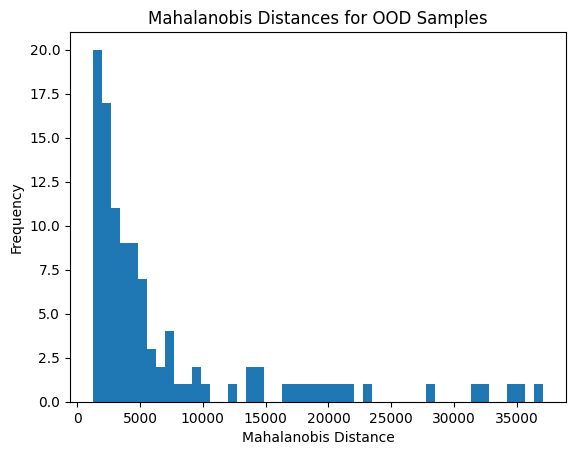

✅ Best Val Accuracy: 0.6866


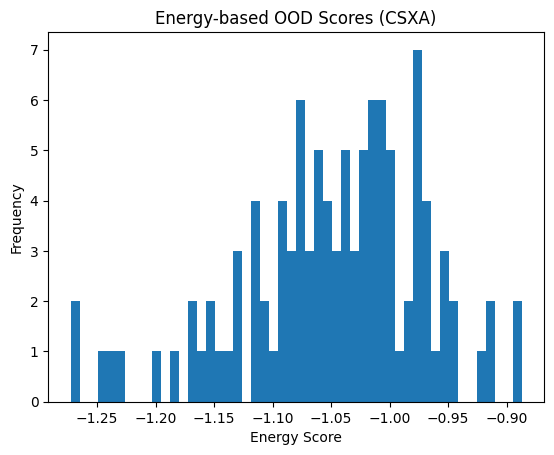

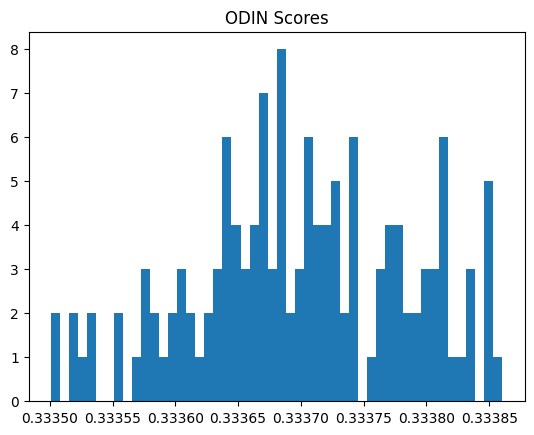

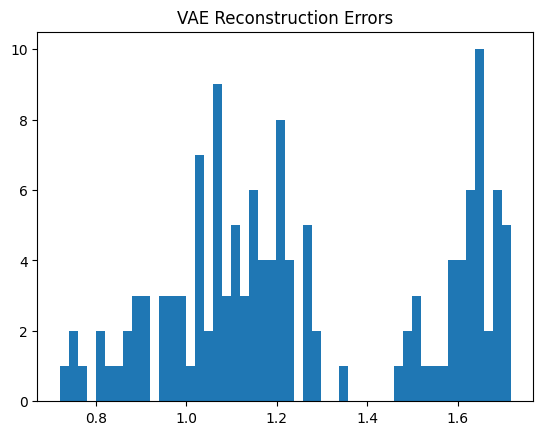

NameError: name 'mahal_distances' is not defined

In [1]:
# IMPORTS & SETUP
# --------------------------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification
import cv2

# --------------------------------------------
# CONFIG
# --------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 3
LR_BACKBONE = 1e-5
LR_HEAD = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# --------------------------------------------
# TRANSFORMS & TTA
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
]

# --------------------------------------------
# DATA SPLIT
# --------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# --------------------------------------------
# SEBlock + Swin Definition
# --------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)
    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# --------------------------------------------
# LOAD & WRAP MODEL
# --------------------------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

# ✅ Unfreeze final block
for name, param in model.named_parameters():
    if name.startswith("swin.encoder.layers.3.blocks.1") or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --------------------------------------------
# Class Balanced Loss + Optimizer
# --------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

backbone_params = [p for n, p in model.named_parameters() if "swin.encoder.layers.3.blocks.1" in n and p.requires_grad]
classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": classifier_params, "lr": LR_HEAD}
], weight_decay=WEIGHT_DECAY)

# --------------------------------------------
# Training Loop + Validation
# --------------------------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)

    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from torchvision.datasets import DatasetFolder
from torchvision.datasets.folder import default_loader

ood_data_dir = "/kaggle/input/testing/Data"

ood_dataset = DatasetFolder(
    root=ood_data_dir,
    loader=default_loader,
    extensions=('jpg', 'jpeg', 'png', 'bmp'),
    transform=test_transform
)

ood_loader = DataLoader(ood_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"OOD Samples: {len(ood_dataset)}")
print(f"OOD Classes: {ood_dataset.classes}")

# 1️⃣ Extract penultimate layer embeddings
def get_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE)
            outputs = model.swin(images)
            # Swin's final transformer block output
            feat = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(feat.cpu().numpy())
            labels.extend(target.numpy())
    return np.vstack(embeddings), np.array(labels)

# # Compute class means and covariances
# train_embeds, train_labels = get_embeddings(train_dataset)
# class_means, class_covs_inv = [], []
# for cls in range(NUM_CLASSES):
#     cls_feats = train_embeds[train_labels == cls]
#     mu = np.mean(cls_feats, axis=0)
#     cov = np.cov(cls_feats, rowvar=False) + np.eye(cls_feats.shape[1]) * 1e-6  # Stabilize
#     cov_inv = inv(cov)
#     class_means.append(mu)
#     class_covs_inv.append(cov_inv)

# # Compute Mahalanobis distance for test set
# test_embeds, test_labels = get_embeddings(test_dataset)
# mahal_distances = []
# for embed in test_embeds:
#     dists = [mahalanobis(embed, mu, cov_inv)
#              for mu, cov_inv in zip(class_means, class_covs_inv)]
#     mahal_distances.append(min(dists))  # Take min distance over classes

# plt.hist(mahal_distances, bins=50)
# plt.title("Mahalanobis Distances")
# plt.show()
# ✅ 1) Compute ID class stats
train_embeds, train_labels = get_embeddings(train_dataset)
class_means, class_covs_inv = [], []
for cls in range(NUM_CLASSES):
    cls_feats = train_embeds[train_labels == cls]
    mu = np.mean(cls_feats, axis=0)
    cov = np.cov(cls_feats, rowvar=False) + np.eye(cls_feats.shape[1]) * 1e-6
    cov_inv = inv(cov)
    class_means.append(mu)
    class_covs_inv.append(cov_inv)

# ✅ 2) Load OOD data (CSXA)
# ood_data_dir = "/kaggle/input/testdata/Data"
# ood_dataset = datasets.ImageFolder(ood_data_dir, transform=test_transform)
ood_embeds, _ = get_embeddings(ood_dataset)

# ✅ 3) Mahalanobis distances for OOD only
ood_mahal_distances = []
for embed in ood_embeds:
    dists = [mahalanobis(embed, mu, cov_inv) for mu, cov_inv in zip(class_means, class_covs_inv)]
    ood_mahal_distances.append(min(dists))

# ✅ 4) Plot and save
plt.hist(ood_mahal_distances, bins=50)
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.title("Mahalanobis Distances for OOD Samples")
plt.show()
# ------------------------------------------------------------
# ✅ ADDITIONAL IMPORTS FOR OOD
# ------------------------------------------------------------
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from scipy.special import logsumexp
import pandas as pd

# ------------------------------------------------------------
# ✅ AFTER TRAINING AND LOADING BEST MODEL
# ------------------------------------------------------------
model.load_state_dict(best_model_state)
model.eval()
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")


# ------------------------------------------------------------
# ✅ 2️⃣ Energy-based OOD Scores
# ------------------------------------------------------------
# def compute_energy(logits, T=1.0):
#     logits_np = logits.cpu().numpy()
#     return -T * logsumexp(logits_np / T, axis=1)

# energy_scores = []
# with torch.no_grad():
#     for images, _ in test_loader:
#         images = images.to(DEVICE)
#         logits = model(images)
#         e = compute_energy(logits)
#         energy_scores.extend(e)

# plt.hist(energy_scores, bins=50)
# plt.title("Energy-based OOD")
# plt.show()
def compute_energy(logits, T=1.0):
    logits_np = logits.cpu().numpy()
    return -T * logsumexp(logits_np / T, axis=1)

energy_scores_ood = []
with torch.no_grad():
    for images, _ in ood_loader:
        images = images.to(DEVICE)
        logits = model(images)
        e = compute_energy(logits)
        energy_scores_ood.extend(e)

plt.hist(energy_scores_ood, bins=50)
plt.xlabel("Energy Score")
plt.ylabel("Frequency")
plt.title("Energy-based OOD Scores (CSXA)")
plt.show()
# ------------------------------------------------------------
# ✅ 3️⃣ ODIN Detector
# ------------------------------------------------------------
def odin_score(x, T=1000, eps=0.0014):
    x = x.clone().detach().requires_grad_(True).to(DEVICE)
    x.retain_grad()  # ✅ fix for .grad

    logits = model(x) / T
    probs = torch.softmax(logits, dim=1)
    max_probs, _ = torch.max(probs, dim=1)
    loss = -torch.mean(torch.log(max_probs))
    loss.backward()
    grad = torch.sign(x.grad.data)

    x_perturbed = x - eps * grad
    logits_p = model(x_perturbed) / T
    probs_p = torch.softmax(logits_p, dim=1)
    max_probs_p, _ = torch.max(probs_p, dim=1)

    return max_probs_p.detach().cpu().numpy()  # ✅ detach to call numpy()



odin_scores = []
for images, _ in test_loader:
    odin_scores.extend(odin_score(images))

plt.hist(odin_scores, bins=50)
plt.title("ODIN Scores")
plt.show()

# ------------------------------------------------------------
# ✅ 4️⃣ OPTIONAL: VAE Reconstruction for OOD
# ------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim*2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 3*224*224),
            nn.Sigmoid()
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon.view(-1, 3, 224, 224), mu, logvar

vae = VAE().to(DEVICE)
# (Train VAE on train_dataset separately if not done)
vae.eval()
recon_errors = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        recon, _, _ = vae(images)
        loss = torch.mean((images - recon)**2, dim=[1,2,3])
        recon_errors.extend(loss.cpu().numpy())

plt.hist(recon_errors, bins=50)
plt.title("VAE Reconstruction Errors")
plt.show()

# ------------------------------------------------------------
# ✅ COMBINE ALL OOD SCORES
# ------------------------------------------------------------
ood_df = pd.DataFrame({
    "Sample": list(range(len(mahal_distances))),
    "Mahalanobis": mahal_distances,
    "Energy": energy_scores,
    "ODIN": odin_scores,
    "VAE_ReconError": recon_errors
})
print("\n✅ Combined OOD Scores")
print(ood_df.head())

ood_df.to_csv("/kaggle/working/ood_scores.csv", index=False)
print("✅ Saved OOD scores to /kaggle/working/ood_scores.csv")

# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")
# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")
# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels
# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)
# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")
# ---------------------------
# Reliability Diagram Helper
# ---------------------------
def plot_reliability(true_labels, probs, name):
    preds = np.argmax(probs, axis=1)
    true_labels_bin = (preds == true_labels).astype(int)
    probs_max = probs.max(axis=1)

    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------
# BETA Calibrated Probabilities
# ---------------------------
beta_probs_raw = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_raw[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_raw /= beta_probs_raw.sum(axis=1, keepdims=True)

beta_probs_tta = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_tta[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_tta /= beta_probs_tta.sum(axis=1, keepdims=True)

# ---------------------------
# RELIABILITY PLOTS
# ---------------------------
plot_reliability(test_labels, probs_raw, "Uncalibrated - Before TTA")
plot_reliability(test_labels, iso_probs_raw, "Isotonic Calibrated - Before TTA")
plot_reliability(test_labels, beta_probs_raw, "Beta Calibrated - Before TTA")

plot_reliability(test_labels, probs_tta, "Uncalibrated - After TTA")
plot_reliability(test_labels, iso_probs_tta, "Isotonic Calibrated - After TTA")
plot_reliability(test_labels, beta_probs_tta, "Beta Calibrated - After TTA")

# ---------------------------
# Evaluate Beta
# ---------------------------
evaluate(beta_probs_raw, test_labels, "Before TTA - Beta Calibrated")
evaluate(beta_probs_tta, test_labels, "After TTA - Beta Calibrated")






2025-07-08 09:50:04.019421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751968204.368789      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751968204.471830      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/3] Train Loss: 41.4871 | Val Loss: 4.8436 | Train Acc: 0.4889 | Val Acc: 0.6716
Epoch [2/3] Train Loss: 36.6627 | Val Loss: 4.3732 | Train Acc: 0.6857 | Val Acc: 0.6866
Epoch [3/3] Train Loss: 33.2797 | Val Loss: 4.0395 | Train Acc: 0.6714 | Val Acc: 0.6866
✅ Best Val Accuracy: 0.6866


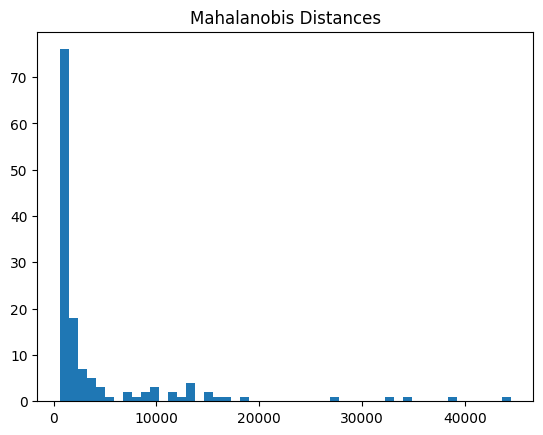

✅ Best Val Accuracy: 0.6866


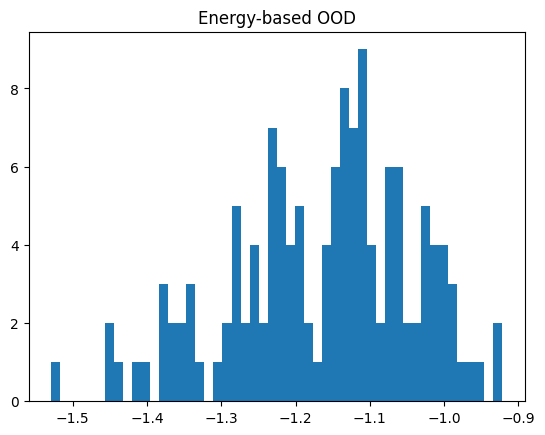

Mean max softmax prob: 0.4982033669948578
Logits mean: -0.1240171417593956
Logits std: 0.4974900186061859


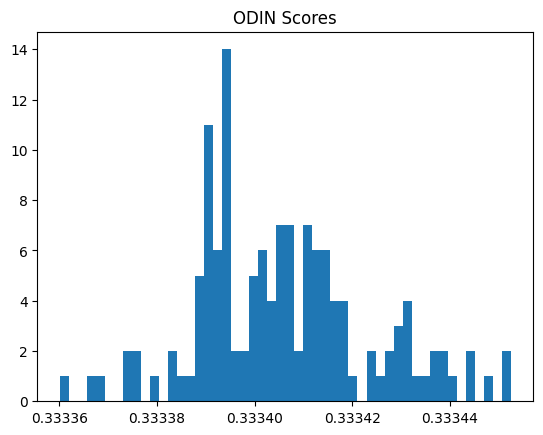

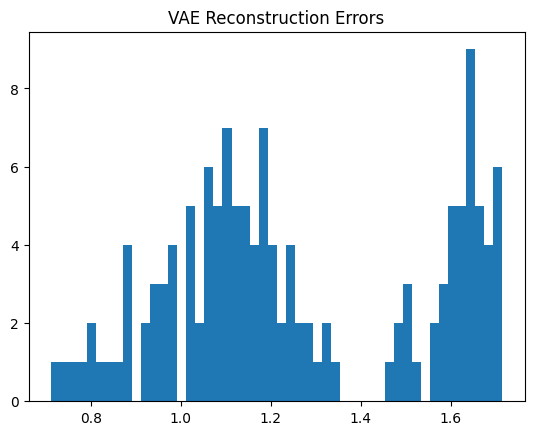


✅ Combined OOD Scores
   Sample  Mahalanobis    Energy      ODIN  VAE_ReconError
0       0  1390.970463 -1.105515  0.333374        1.205229
1       1  2063.387062 -1.029105  0.333408        1.170839
2       2  3661.347332 -1.133932  0.333404        1.696419
3       3  3644.066332 -1.009640  0.333407        1.345164
4       4  1378.155956 -1.074398  0.333394        1.320771
✅ Saved OOD scores to /kaggle/working/ood_scores.csv
Vector Scaling Temperatures: [1.02698682 0.5        0.63296099]
Conformal quantile: 0.8305


/tmp/ipykernel_35/1128295362.py:420: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()



✅ Before TTA - Isotonic Calibrated RESULTS
AUC: 0.7756
                          precision    recall  f1-score   support

      Normal_New_Process       0.81      0.64      0.72        45
Osteoporosis_New_Process       0.71      0.53      0.61        45
   Ostopenia_New_Process       0.60      0.87      0.71        45

                accuracy                           0.68       135
               macro avg       0.70      0.68      0.68       135
            weighted avg       0.70      0.68      0.68       135

ECE: 0.2082 | MCE: 0.6301


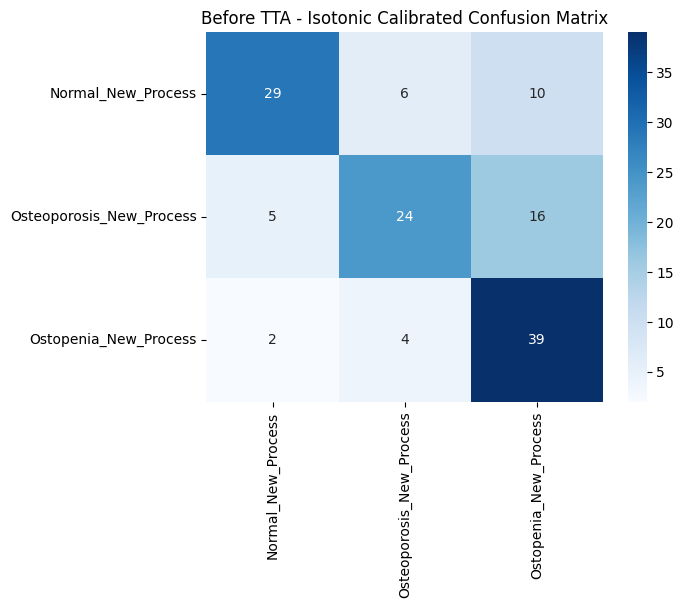


✅ Before TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8444
Avg Set Size: 2.01

✅ After TTA - Isotonic Calibrated RESULTS
AUC: 0.7756
                          precision    recall  f1-score   support

      Normal_New_Process       0.82      0.60      0.69        45
Osteoporosis_New_Process       0.67      0.53      0.59        45
   Ostopenia_New_Process       0.61      0.89      0.72        45

                accuracy                           0.67       135
               macro avg       0.70      0.67      0.67       135
            weighted avg       0.70      0.67      0.67       135

ECE: 0.1268 | MCE: 0.3077


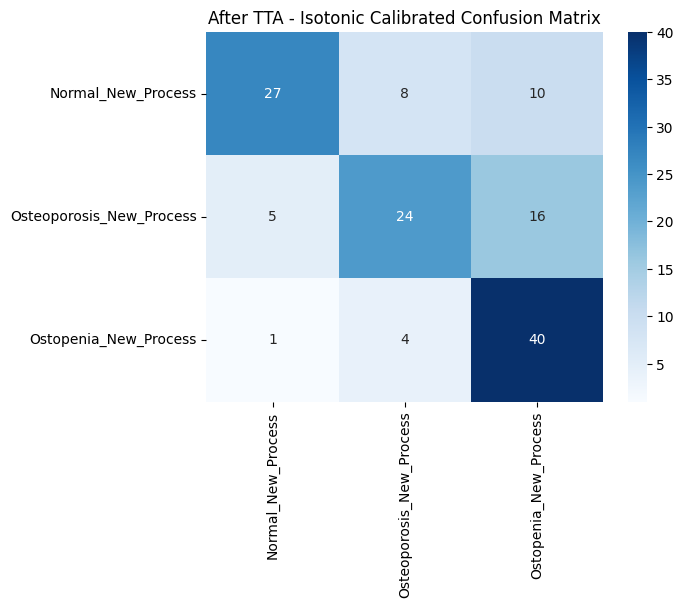


✅ After TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8593
Avg Set Size: 2.06


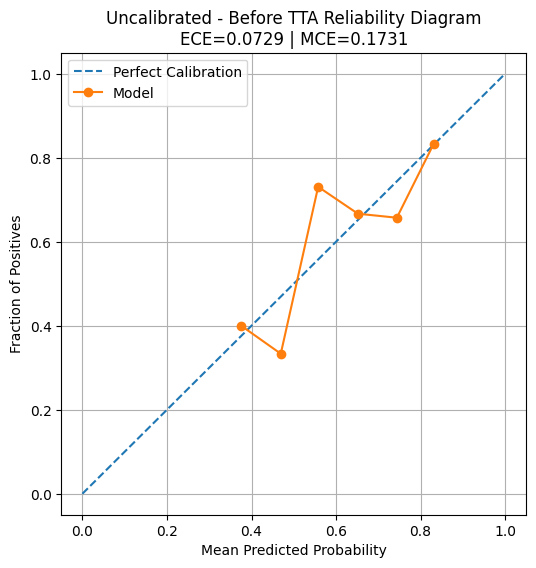

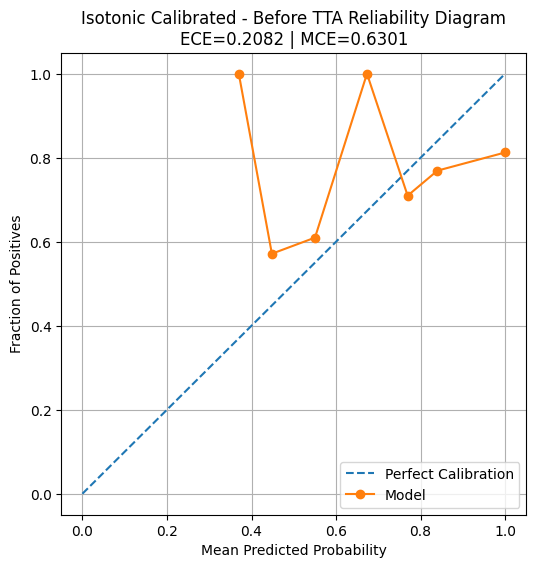

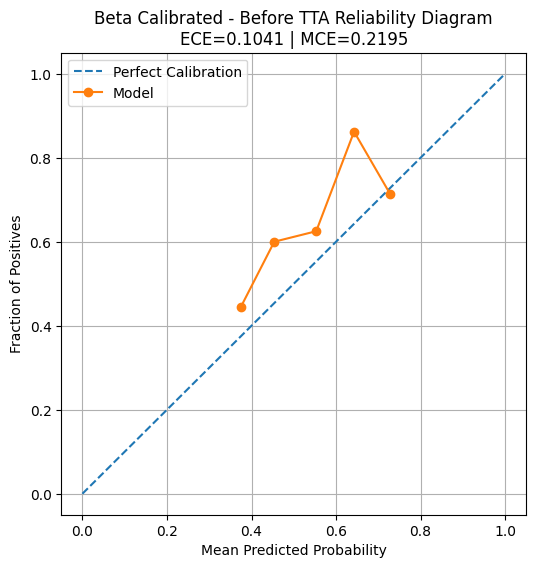

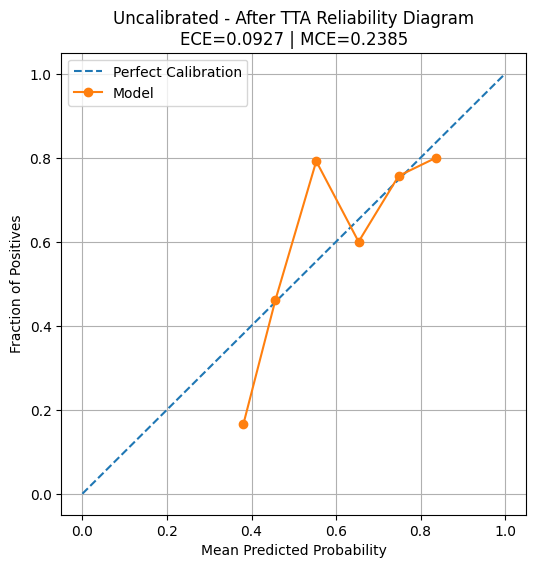

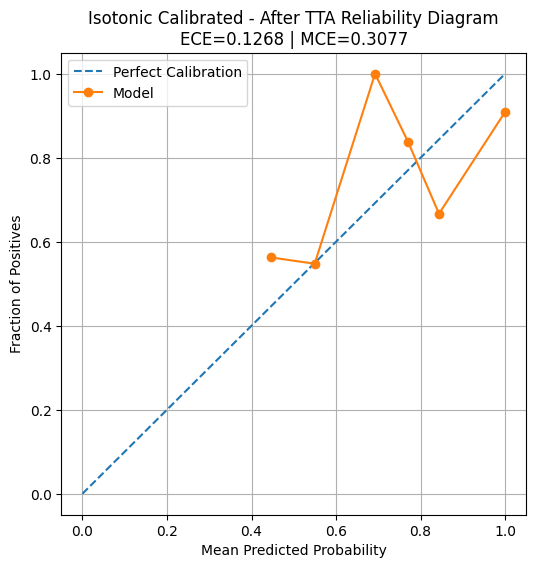

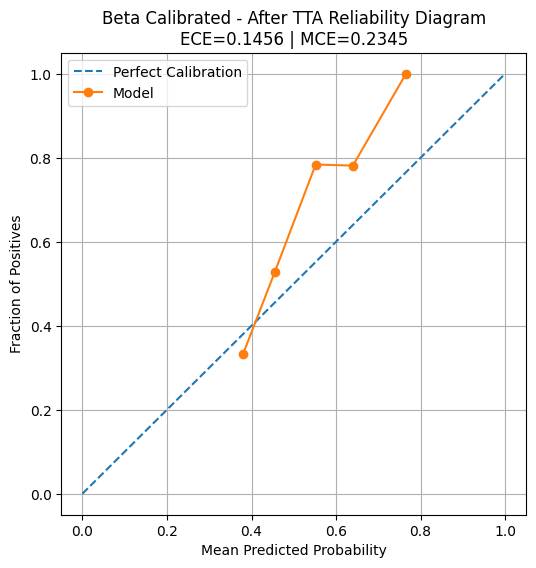


✅ Before TTA - Beta Calibrated RESULTS
AUC: 0.7686
                          precision    recall  f1-score   support

      Normal_New_Process       0.70      0.67      0.68        45
Osteoporosis_New_Process       0.73      0.42      0.54        45
   Ostopenia_New_Process       0.61      0.89      0.72        45

                accuracy                           0.66       135
               macro avg       0.68      0.66      0.65       135
            weighted avg       0.68      0.66      0.65       135

ECE: 0.1041 | MCE: 0.2195


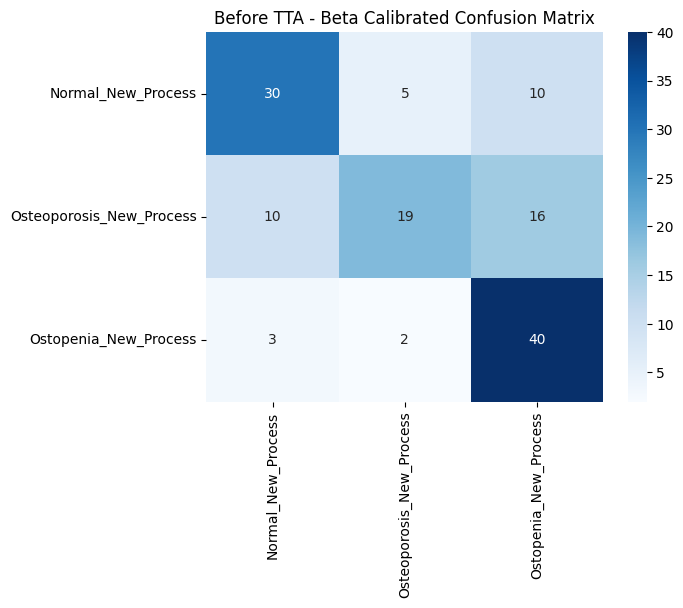


✅ After TTA - Beta Calibrated RESULTS
AUC: 0.7748
                          precision    recall  f1-score   support

      Normal_New_Process       0.73      0.60      0.66        45
Osteoporosis_New_Process       0.62      0.44      0.52        45
   Ostopenia_New_Process       0.61      0.89      0.72        45

                accuracy                           0.64       135
               macro avg       0.65      0.64      0.63       135
            weighted avg       0.65      0.64      0.63       135

ECE: 0.1456 | MCE: 0.2345


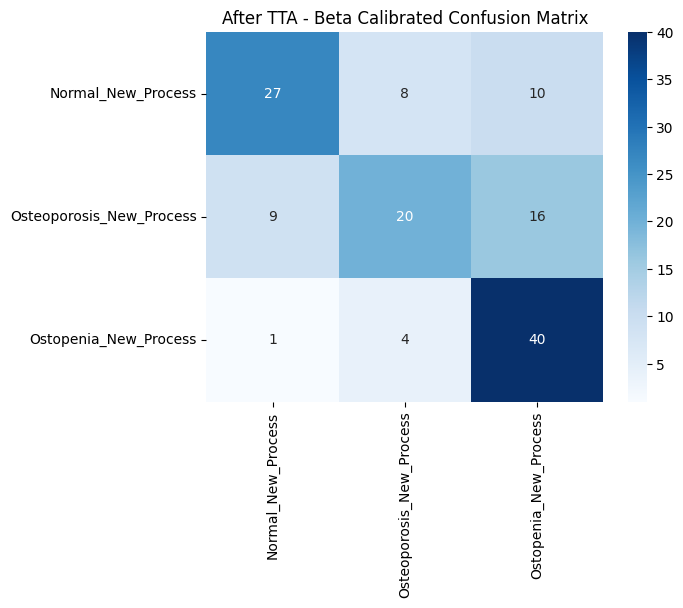

In [1]:
# IMPORTS & SETUP
# --------------------------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification
import cv2

# --------------------------------------------
# CONFIG
# --------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 3
LR_BACKBONE = 1e-5
LR_HEAD = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# --------------------------------------------
# TRANSFORMS & TTA
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
]

# --------------------------------------------
# DATA SPLIT
# --------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# --------------------------------------------
# SEBlock + Swin Definition
# --------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)
    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# --------------------------------------------
# LOAD & WRAP MODEL
# --------------------------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

# ✅ Unfreeze final block
for name, param in model.named_parameters():
    if name.startswith("swin.encoder.layers.3.blocks.1") or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --------------------------------------------
# Class Balanced Loss + Optimizer
# --------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

backbone_params = [p for n, p in model.named_parameters() if "swin.encoder.layers.3.blocks.1" in n and p.requires_grad]
classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": classifier_params, "lr": LR_HEAD}
], weight_decay=WEIGHT_DECAY)

# --------------------------------------------
# Training Loop + Validation
# --------------------------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)

    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from torchvision.datasets import DatasetFolder
from torchvision.datasets.folder import default_loader



# 1️⃣ Extract penultimate layer embeddings
def get_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE)
            outputs = model.swin(images)
            # Swin's final transformer block output
            feat = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(feat.cpu().numpy())
            labels.extend(target.numpy())
    return np.vstack(embeddings), np.array(labels)

# # Compute class means and covariances
train_embeds, train_labels = get_embeddings(train_dataset)
class_means, class_covs_inv = [], []
for cls in range(NUM_CLASSES):
    cls_feats = train_embeds[train_labels == cls]
    mu = np.mean(cls_feats, axis=0)
    cov = np.cov(cls_feats, rowvar=False) + np.eye(cls_feats.shape[1]) * 1e-6  # Stabilize
    cov_inv = inv(cov)
    class_means.append(mu)
    class_covs_inv.append(cov_inv)

# Compute Mahalanobis distance for test set
test_embeds, test_labels = get_embeddings(test_dataset)
mahal_distances = []
for embed in test_embeds:
    dists = [mahalanobis(embed, mu, cov_inv)
             for mu, cov_inv in zip(class_means, class_covs_inv)]
    mahal_distances.append(min(dists))  # Take min distance over classes

plt.hist(mahal_distances, bins=50)
plt.title("Mahalanobis Distances")
plt.show()
# ✅ 1) Compute ID class stats

# ------------------------------------------------------------
# ✅ ADDITIONAL IMPORTS FOR OOD
# ------------------------------------------------------------
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from scipy.special import logsumexp
import pandas as pd

# ------------------------------------------------------------
# ✅ AFTER TRAINING AND LOADING BEST MODEL
# ------------------------------------------------------------
model.load_state_dict(best_model_state)
model.eval()
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")


# ------------------------------------------------------------
# ✅ 2️⃣ Energy-based OOD Scores
# ------------------------------------------------------------
def compute_energy(logits, T=1.0):
    logits_np = logits.cpu().numpy()
    return -T * logsumexp(logits_np / T, axis=1)

energy_scores = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        e = compute_energy(logits)
        energy_scores.extend(e)

plt.hist(energy_scores, bins=50)
plt.title("Energy-based OOD")
plt.show()
softmax_probs = torch.softmax(logits, dim=1)
max_probs = torch.max(softmax_probs, dim=1).values
print("Mean max softmax prob:", max_probs.mean().item())

print("Logits mean:", logits.mean().item())
print("Logits std:", logits.std().item())

# ------------------------------------------------------------
# ✅ 3️⃣ ODIN Detector
# ------------------------------------------------------------
def odin_score(x, T=5000, eps=0.005):
    x = x.clone().detach().requires_grad_(True).to(DEVICE)
    x.retain_grad()  # ✅ fix for .grad

    logits = model(x) / T
    probs = torch.softmax(logits, dim=1)
    max_probs, _ = torch.max(probs, dim=1)
    loss = -torch.mean(torch.log(max_probs))
    loss.backward()
    grad = torch.sign(x.grad.data)

    x_perturbed = x - eps * grad
    logits_p = model(x_perturbed) / T
    probs_p = torch.softmax(logits_p, dim=1)
    max_probs_p, _ = torch.max(probs_p, dim=1)

    return max_probs_p.detach().cpu().numpy()  # ✅ detach to call numpy()



odin_scores = []
for images, _ in test_loader:
    odin_scores.extend(odin_score(images))

plt.hist(odin_scores, bins=50)
plt.title("ODIN Scores")
plt.show()

# ------------------------------------------------------------
# ✅ 4️⃣ OPTIONAL: VAE Reconstruction for OOD
# ------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim*2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 3*224*224),
            nn.Sigmoid()
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon.view(-1, 3, 224, 224), mu, logvar

vae = VAE().to(DEVICE)
# (Train VAE on train_dataset separately if not done)
vae.eval()
recon_errors = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        recon, _, _ = vae(images)
        loss = torch.mean((images - recon)**2, dim=[1,2,3])
        recon_errors.extend(loss.cpu().numpy())

plt.hist(recon_errors, bins=50)
plt.title("VAE Reconstruction Errors")
plt.show()

# ------------------------------------------------------------
# ✅ COMBINE ALL OOD SCORES
# ------------------------------------------------------------
ood_df = pd.DataFrame({
    "Sample": list(range(len(mahal_distances))),
    "Mahalanobis": mahal_distances,
    "Energy": energy_scores,
    "ODIN": odin_scores,
    "VAE_ReconError": recon_errors
})
print("\n✅ Combined OOD Scores")
print(ood_df.head())

ood_df.to_csv("/kaggle/working/ood_scores.csv", index=False)
print("✅ Saved OOD scores to /kaggle/working/ood_scores.csv")

# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")
# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")
# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels
# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)
# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")
# ---------------------------
# Reliability Diagram Helper
# ---------------------------
def plot_reliability(true_labels, probs, name):
    preds = np.argmax(probs, axis=1)
    true_labels_bin = (preds == true_labels).astype(int)
    probs_max = probs.max(axis=1)

    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------
# BETA Calibrated Probabilities
# ---------------------------
beta_probs_raw = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_raw[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_raw /= beta_probs_raw.sum(axis=1, keepdims=True)

beta_probs_tta = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_tta[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_tta /= beta_probs_tta.sum(axis=1, keepdims=True)

# ---------------------------
# RELIABILITY PLOTS
# ---------------------------
plot_reliability(test_labels, probs_raw, "Uncalibrated - Before TTA")
plot_reliability(test_labels, iso_probs_raw, "Isotonic Calibrated - Before TTA")
plot_reliability(test_labels, beta_probs_raw, "Beta Calibrated - Before TTA")

plot_reliability(test_labels, probs_tta, "Uncalibrated - After TTA")
plot_reliability(test_labels, iso_probs_tta, "Isotonic Calibrated - After TTA")
plot_reliability(test_labels, beta_probs_tta, "Beta Calibrated - After TTA")

# ---------------------------
# Evaluate Beta
# ---------------------------
evaluate(beta_probs_raw, test_labels, "Before TTA - Beta Calibrated")
evaluate(beta_probs_tta, test_labels, "After TTA - Beta Calibrated")






2025-07-08 14:01:40.761519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751983301.123231      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751983301.228161      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/60] Train Loss: 39.0281 | Val Loss: 4.3810 | Train Acc: 0.5889 | Val Acc: 0.6866
Epoch [2/60] Train Loss: 33.1228 | Val Loss: 4.0393 | Train Acc: 0.6921 | Val Acc: 0.6866
Epoch [3/60] Train Loss: 31.2550 | Val Loss: 3.8668 | Train Acc: 0.6952 | Val Acc: 0.7015
Epoch [4/60] Train Loss: 30.2159 | Val Loss: 3.7650 | Train Acc: 0.7048 | Val Acc: 0.7313
Epoch [5/60] Train Loss: 29.5744 | Val Loss: 3.7569 | Train Acc: 0.7190 | Val Acc: 0.7313
Epoch [6/60] Train Loss: 28.8503 | Val Loss: 3.7017 | Train Acc: 0.7270 | Val Acc: 0.7015
Epoch [7/60] Train Loss: 28.9769 | Val Loss: 3.6066 | Train Acc: 0.7397 | Val Acc: 0.7015
Epoch [8/60] Train Loss: 28.1726 | Val Loss: 3.6424 | Train Acc: 0.7444 | Val Acc: 0.7313
Epoch [9/60] Train Loss: 28.0919 | Val Loss: 3.6023 | Train Acc: 0.7714 | Val Acc: 0.7015
Epoch [10/60] Train Loss: 28.4544 | Val Loss: 3.5720 | Train Acc: 0.7349 | Val Acc: 0.7463
Epoch [11/60] Train Loss: 28.0958 | Val Loss: 3.3620 | Train Acc: 0.7460 | Val Acc: 0.7015
Epoch [1

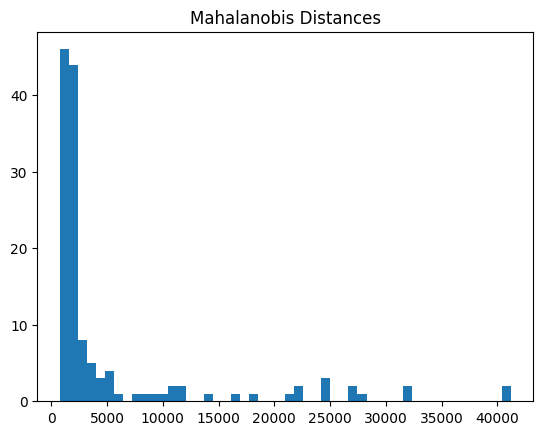

✅ Best Val Accuracy: 0.8060


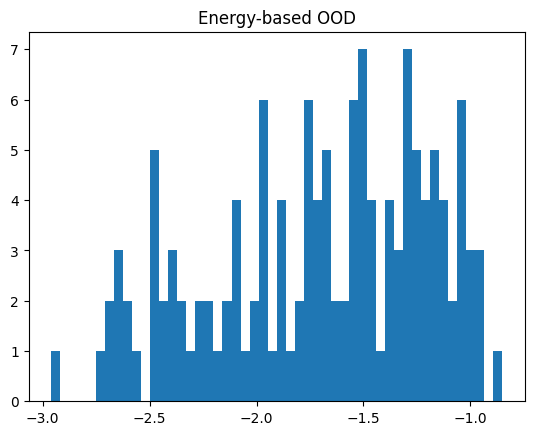

Mean max softmax prob: 0.6281555891036987
Logits mean: -0.19883155822753906
Logits std: 1.1005185842514038


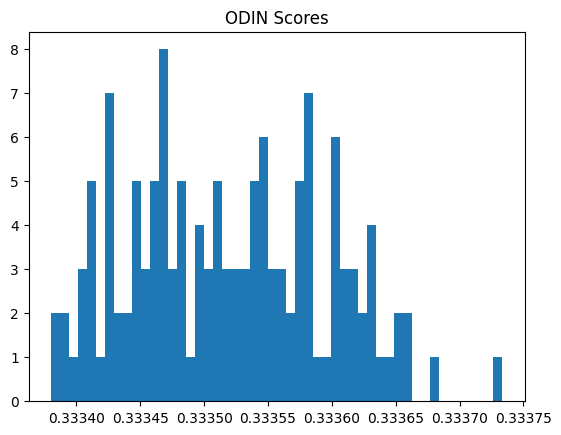

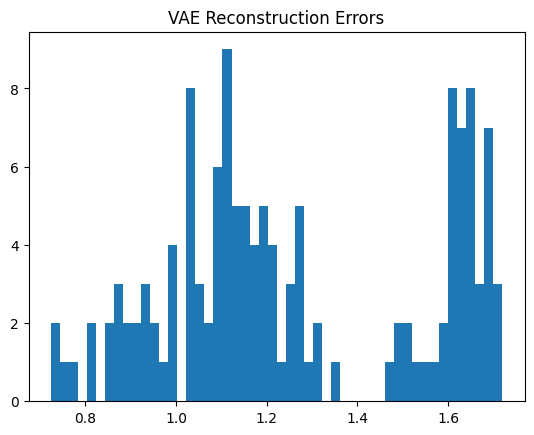


✅ Combined OOD Scores
   Sample   Mahalanobis    Energy      ODIN  VAE_ReconError
0       0   1542.031080 -1.230380  0.333466        1.210740
1       1   1697.549887 -1.703421  0.333626        1.207027
2       2   6271.860312 -1.302424  0.333480        1.697694
3       3   1575.834596 -1.170365  0.333469        1.345686
4       4  24496.929568 -1.256042  0.333511        1.314023
✅ Saved OOD scores to /kaggle/working/ood_scores.csv
Vector Scaling Temperatures: [1.59207771 0.86709213 0.90610212]
Conformal quantile: 0.7844


/tmp/ipykernel_35/3364508790.py:428: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()



✅ Before TTA - Isotonic Calibrated RESULTS
AUC: 0.8266
                          precision    recall  f1-score   support

      Normal_New_Process       0.82      0.60      0.69        45
Osteoporosis_New_Process       0.70      0.62      0.66        45
   Ostopenia_New_Process       0.63      0.87      0.73        45

                accuracy                           0.70       135
               macro avg       0.72      0.70      0.69       135
            weighted avg       0.72      0.70      0.69       135

ECE: 0.0861 | MCE: 0.1610


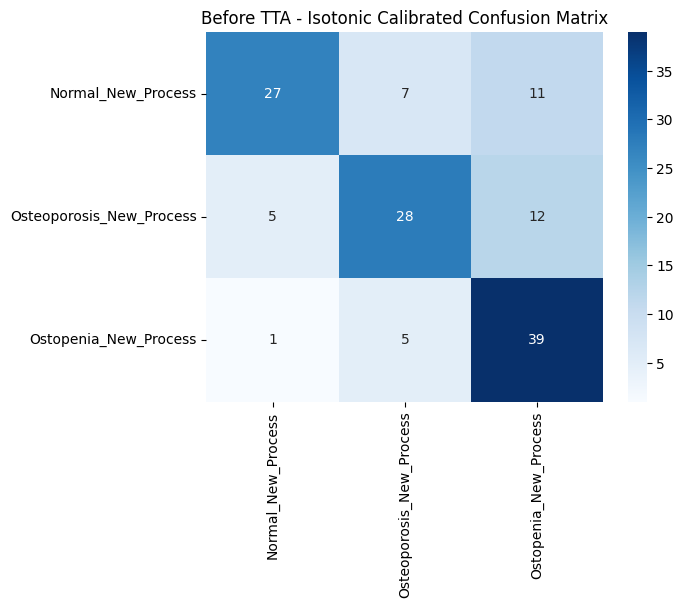


✅ Before TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8444
Avg Set Size: 1.50

✅ After TTA - Isotonic Calibrated RESULTS
AUC: 0.8394
                          precision    recall  f1-score   support

      Normal_New_Process       0.86      0.69      0.77        45
Osteoporosis_New_Process       0.71      0.56      0.63        45
   Ostopenia_New_Process       0.64      0.91      0.75        45

                accuracy                           0.72       135
               macro avg       0.74      0.72      0.71       135
            weighted avg       0.74      0.72      0.71       135

ECE: 0.0731 | MCE: 0.1274


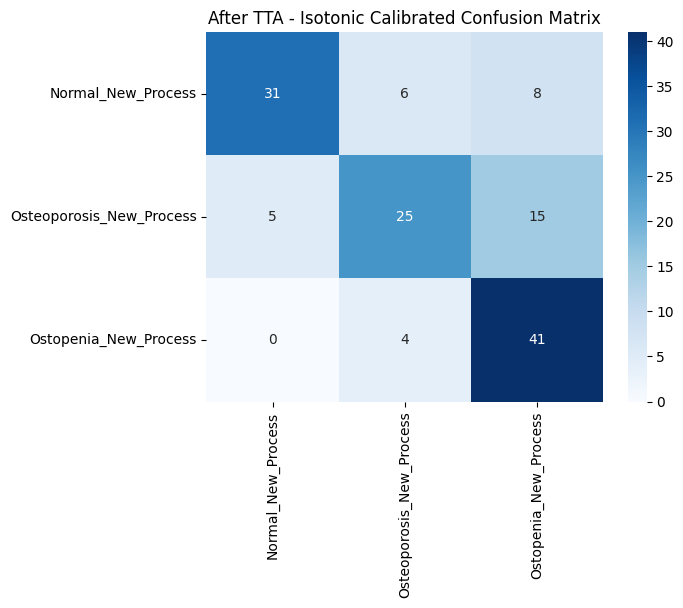


✅ After TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8667
Avg Set Size: 1.56


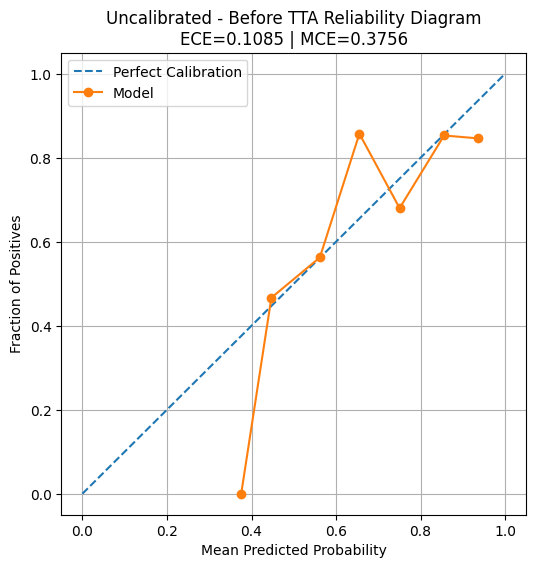

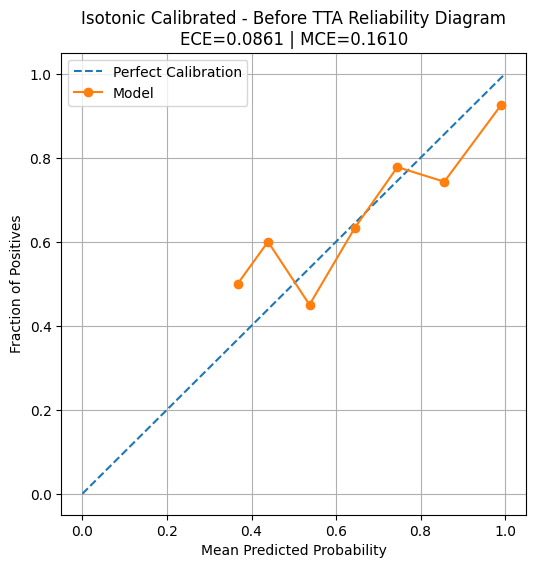

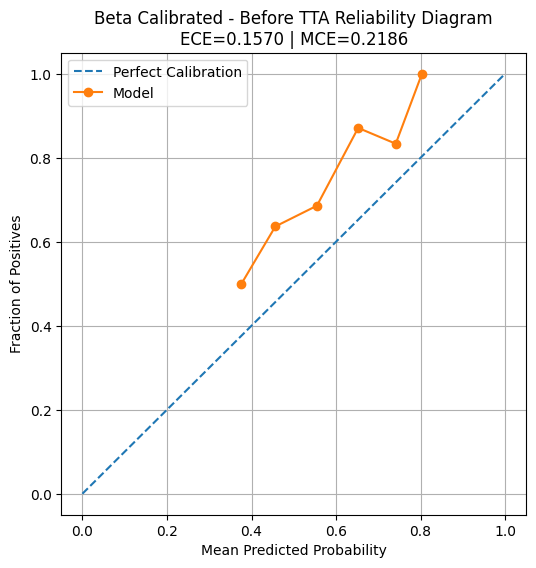

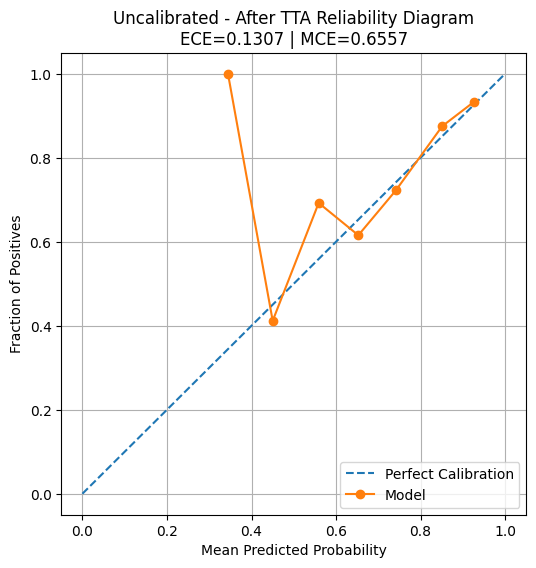

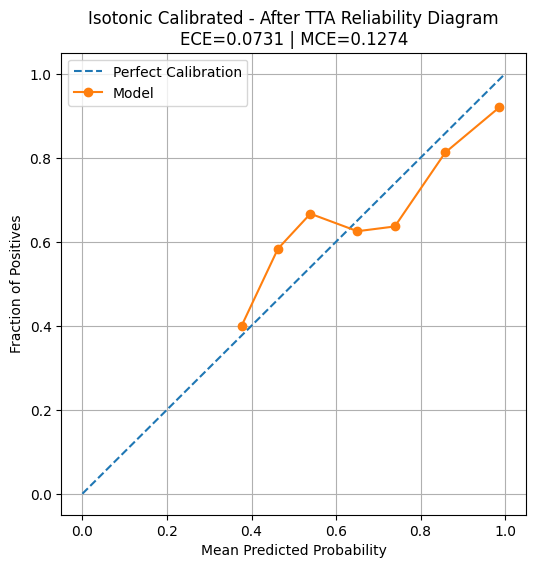

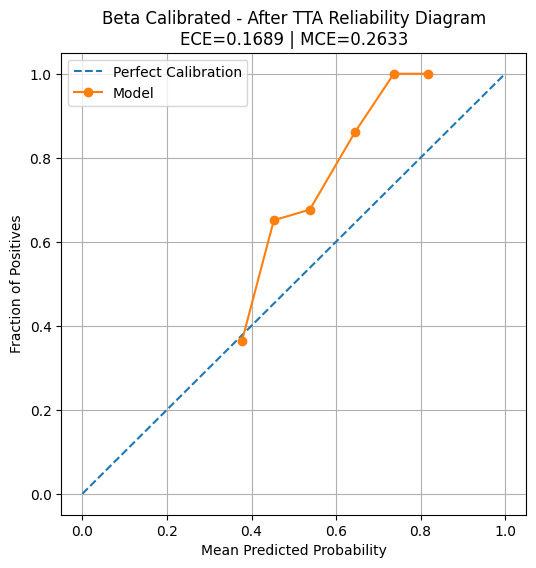


✅ Before TTA - Beta Calibrated RESULTS
AUC: 0.8404
                          precision    recall  f1-score   support

      Normal_New_Process       0.79      0.67      0.72        45
Osteoporosis_New_Process       0.74      0.56      0.63        45
   Ostopenia_New_Process       0.65      0.91      0.76        45

                accuracy                           0.71       135
               macro avg       0.73      0.71      0.71       135
            weighted avg       0.73      0.71      0.71       135

ECE: 0.1570 | MCE: 0.2186


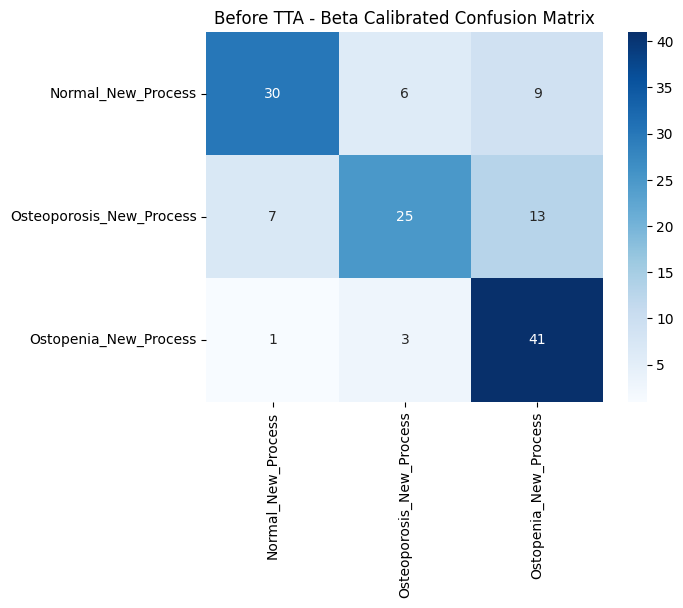


✅ After TTA - Beta Calibrated RESULTS
AUC: 0.8451
                          precision    recall  f1-score   support

      Normal_New_Process       0.84      0.69      0.76        45
Osteoporosis_New_Process       0.73      0.53      0.62        45
   Ostopenia_New_Process       0.65      0.93      0.76        45

                accuracy                           0.72       135
               macro avg       0.74      0.72      0.71       135
            weighted avg       0.74      0.72      0.71       135

ECE: 0.1689 | MCE: 0.2633


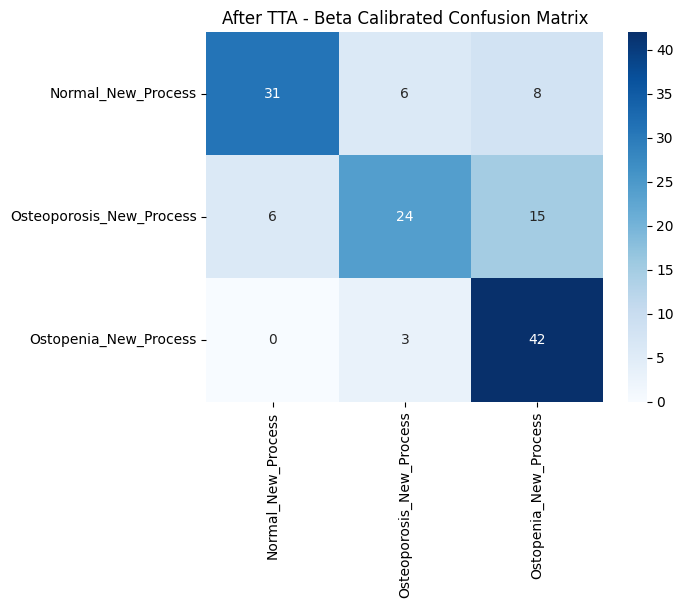

In [1]:
# IMPORTS & SETUP
# --------------------------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification
import cv2

# --------------------------------------------
# CONFIG
# --------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 60
LR_BACKBONE = 5e-6
LR_HEAD = 5e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# --------------------------------------------
# TRANSFORMS & TTA
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
]

# --------------------------------------------
# DATA SPLIT
# --------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# --------------------------------------------
# SEBlock + Swin Definition
# --------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)
    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# --------------------------------------------
# LOAD & WRAP MODEL
# --------------------------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

# ✅ Unfreeze final block
for name, param in model.named_parameters():
    if name.startswith("swin.encoder.layers.3.blocks.1") or name.startswith("swin.encoder.layers.3.blocks.0") or name.startswith("swin.encoder.layers.2.blocks.5") or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --------------------------------------------
# Class Balanced Loss + Optimizer
# --------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights_tensor,label_smoothing=0.1)

backbone_params = [
    p for n, p in model.named_parameters()
    if (
        n.startswith("swin.encoder.layers.3.blocks.0") or
        n.startswith("swin.encoder.layers.3.blocks.1") or
        n.startswith("swin.encoder.layers.2.blocks.5")
    ) and p.requires_grad
]
classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": classifier_params, "lr": LR_HEAD}
], weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# --------------------------------------------
# Training Loop + Validation
# --------------------------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    train_acc = total_correct / len(train_dataset)

    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)
    scheduler.step()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from torchvision.datasets import DatasetFolder
from torchvision.datasets.folder import default_loader



# 1️⃣ Extract penultimate layer embeddings
def get_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE)
            outputs = model.swin(images)
            # Swin's final transformer block output
            feat = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(feat.cpu().numpy())
            labels.extend(target.numpy())
    return np.vstack(embeddings), np.array(labels)

# # Compute class means and covariances
train_embeds, train_labels = get_embeddings(train_dataset)
class_means, class_covs_inv = [], []
for cls in range(NUM_CLASSES):
    cls_feats = train_embeds[train_labels == cls]
    mu = np.mean(cls_feats, axis=0)
    cov = np.cov(cls_feats, rowvar=False) + np.eye(cls_feats.shape[1]) * 1e-6  # Stabilize
    cov_inv = inv(cov)
    class_means.append(mu)
    class_covs_inv.append(cov_inv)

# Compute Mahalanobis distance for test set
test_embeds, test_labels = get_embeddings(test_dataset)
mahal_distances = []
for embed in test_embeds:
    dists = [mahalanobis(embed, mu, cov_inv)
             for mu, cov_inv in zip(class_means, class_covs_inv)]
    mahal_distances.append(min(dists))  # Take min distance over classes

plt.hist(mahal_distances, bins=50)
plt.title("Mahalanobis Distances")
plt.show()
# ✅ 1) Compute ID class stats

# ------------------------------------------------------------
# ✅ ADDITIONAL IMPORTS FOR OOD
# ------------------------------------------------------------
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from scipy.special import logsumexp
import pandas as pd

# ------------------------------------------------------------
# ✅ AFTER TRAINING AND LOADING BEST MODEL
# ------------------------------------------------------------
model.load_state_dict(best_model_state)
model.eval()
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")


# ------------------------------------------------------------
# ✅ 2️⃣ Energy-based OOD Scores
# ------------------------------------------------------------
def compute_energy(logits, T=1.0):
    logits_np = logits.cpu().numpy()
    return -T * logsumexp(logits_np / T, axis=1)

energy_scores = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        e = compute_energy(logits)
        energy_scores.extend(e)

plt.hist(energy_scores, bins=50)
plt.title("Energy-based OOD")
plt.show()
softmax_probs = torch.softmax(logits, dim=1)
max_probs = torch.max(softmax_probs, dim=1).values
print("Mean max softmax prob:", max_probs.mean().item())

print("Logits mean:", logits.mean().item())
print("Logits std:", logits.std().item())

# ------------------------------------------------------------
# ✅ 3️⃣ ODIN Detector
# ------------------------------------------------------------
def odin_score(x, T=5000, eps=0.005):
    x = x.clone().detach().requires_grad_(True).to(DEVICE)
    x.retain_grad()  # ✅ fix for .grad

    logits = model(x) / T
    probs = torch.softmax(logits, dim=1)
    max_probs, _ = torch.max(probs, dim=1)
    loss = -torch.mean(torch.log(max_probs))
    loss.backward()
    grad = torch.sign(x.grad.data)

    x_perturbed = x - eps * grad
    logits_p = model(x_perturbed) / T
    probs_p = torch.softmax(logits_p, dim=1)
    max_probs_p, _ = torch.max(probs_p, dim=1)

    return max_probs_p.detach().cpu().numpy()  # ✅ detach to call numpy()



odin_scores = []
for images, _ in test_loader:
    odin_scores.extend(odin_score(images))

plt.hist(odin_scores, bins=50)
plt.title("ODIN Scores")
plt.show()

# ------------------------------------------------------------
# ✅ 4️⃣ OPTIONAL: VAE Reconstruction for OOD
# ------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim*2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 3*224*224),
            nn.Sigmoid()
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon.view(-1, 3, 224, 224), mu, logvar

vae = VAE().to(DEVICE)
# (Train VAE on train_dataset separately if not done)
vae.eval()
recon_errors = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        recon, _, _ = vae(images)
        loss = torch.mean((images - recon)**2, dim=[1,2,3])
        recon_errors.extend(loss.cpu().numpy())

plt.hist(recon_errors, bins=50)
plt.title("VAE Reconstruction Errors")
plt.show()

# ------------------------------------------------------------
# ✅ COMBINE ALL OOD SCORES
# ------------------------------------------------------------
ood_df = pd.DataFrame({
    "Sample": list(range(len(mahal_distances))),
    "Mahalanobis": mahal_distances,
    "Energy": energy_scores,
    "ODIN": odin_scores,
    "VAE_ReconError": recon_errors
})
print("\n✅ Combined OOD Scores")
print(ood_df.head())

ood_df.to_csv("/kaggle/working/ood_scores.csv", index=False)
print("✅ Saved OOD scores to /kaggle/working/ood_scores.csv")

# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")
# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")
# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels
# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)
# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")
# ---------------------------
# Reliability Diagram Helper
# ---------------------------
def plot_reliability(true_labels, probs, name):
    preds = np.argmax(probs, axis=1)
    true_labels_bin = (preds == true_labels).astype(int)
    probs_max = probs.max(axis=1)

    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------
# BETA Calibrated Probabilities
# ---------------------------
beta_probs_raw = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_raw[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_raw /= beta_probs_raw.sum(axis=1, keepdims=True)

beta_probs_tta = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_tta[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_tta /= beta_probs_tta.sum(axis=1, keepdims=True)

# ---------------------------
# RELIABILITY PLOTS
# ---------------------------
plot_reliability(test_labels, probs_raw, "Uncalibrated - Before TTA")
plot_reliability(test_labels, iso_probs_raw, "Isotonic Calibrated - Before TTA")
plot_reliability(test_labels, beta_probs_raw, "Beta Calibrated - Before TTA")

plot_reliability(test_labels, probs_tta, "Uncalibrated - After TTA")
plot_reliability(test_labels, iso_probs_tta, "Isotonic Calibrated - After TTA")
plot_reliability(test_labels, beta_probs_tta, "Beta Calibrated - After TTA")

# ---------------------------
# Evaluate Beta
# ---------------------------
evaluate(beta_probs_raw, test_labels, "Before TTA - Beta Calibrated")
evaluate(beta_probs_tta, test_labels, "After TTA - Beta Calibrated")






2025-07-09 11:09:43.672764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752059384.036457      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752059384.142654      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/1] — Unfrozen blocks: Only Classifier
Epoch [1/1] Train Loss: 39.8406 | Val Loss: 4.5639 | Train Acc: 0.5857 | Val Acc: 0.6866 | LR: [0.0, 0.0]
✅ Best Val Accuracy: 0.6866
✅ Best Val Accuracy: 0.6866


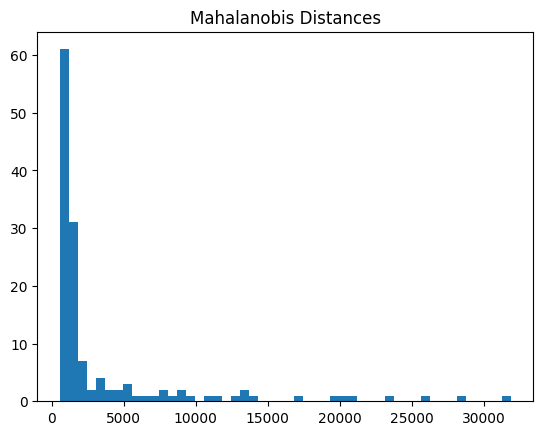

Mean Epistemic Uncertainty (entropy): 1.0198


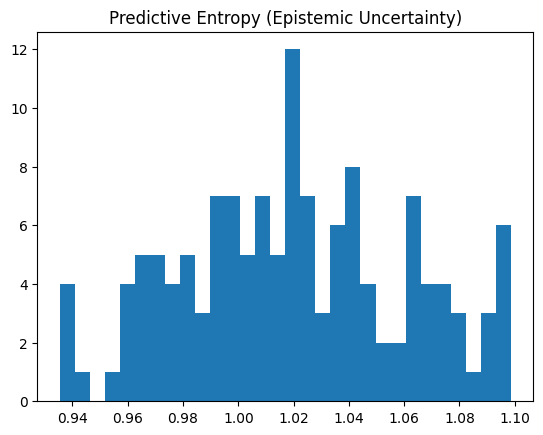


✅ MC Dropout - Epistemic Uncertainty RESULTS
AUC: 0.7639
                          precision    recall  f1-score   support

      Normal_New_Process       0.90      0.58      0.70        45
Osteoporosis_New_Process       0.71      0.56      0.63        45
   Ostopenia_New_Process       0.58      0.91      0.71        45

                accuracy                           0.68       135
               macro avg       0.73      0.68      0.68       135
            weighted avg       0.73      0.68      0.68       135

ECE: 0.1345 | MCE: 0.2440


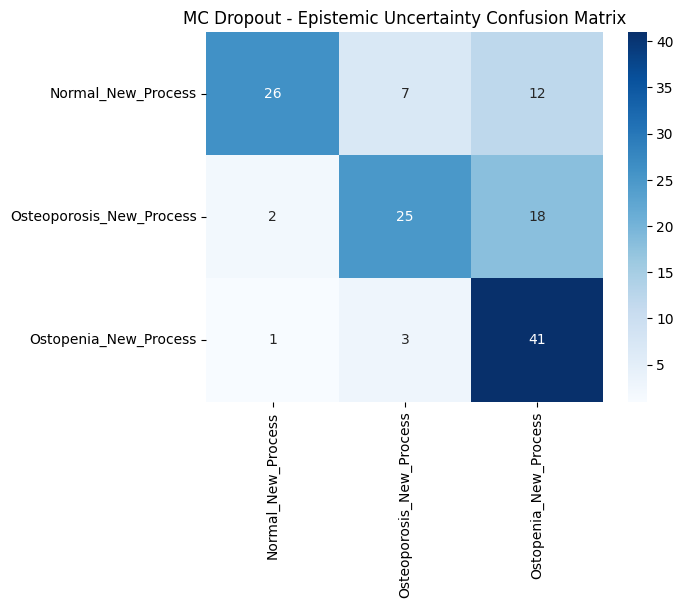

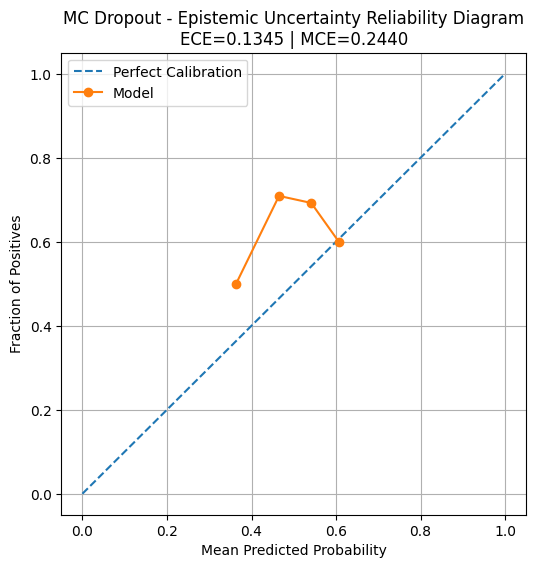

✅ Best Val Accuracy: 0.6866


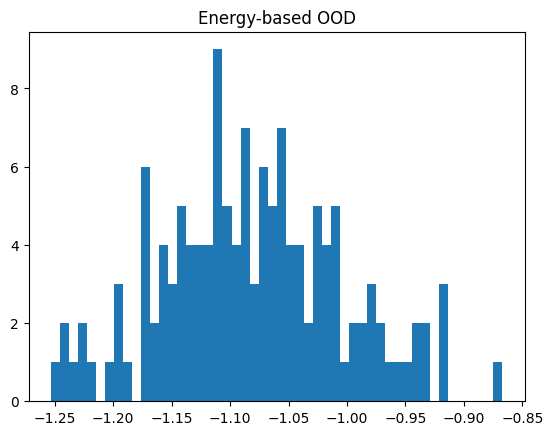

Mean max softmax prob: 0.48402026295661926
Logits mean: -0.09578060358762741
Logits std: 0.36402860283851624


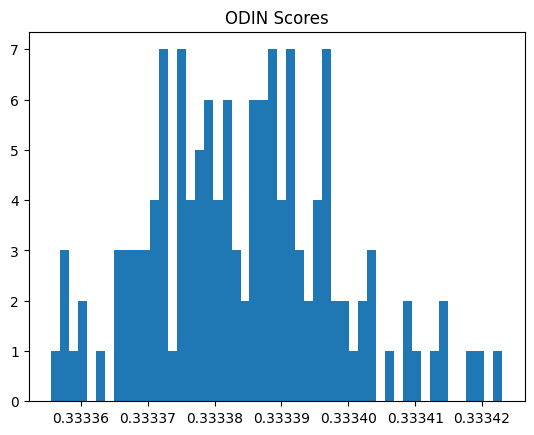

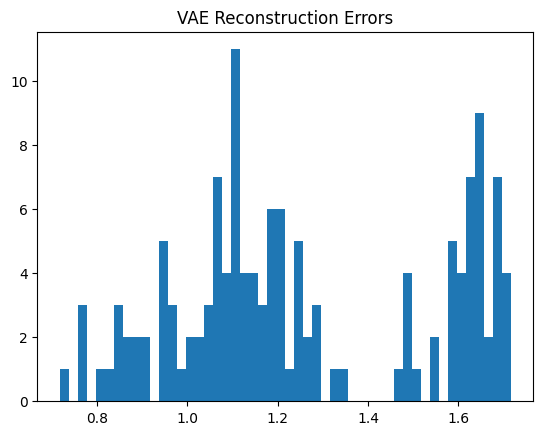


✅ Combined OOD Scores
   Sample  Mahalanobis    Energy      ODIN  VAE_ReconError
0       0   847.196543 -1.109493  0.333373        1.211611
1       1  1558.579026 -1.036391  0.333366        1.180320
2       2  4058.350249 -1.118107  0.333404        1.692136
3       3  1173.160691 -1.088826  0.333383        1.344324
4       4   579.058742 -1.103127  0.333372        1.290870
✅ Saved OOD scores to /kaggle/working/ood_scores.csv
Vector Scaling Temperatures: [0.74514853 0.5        0.5       ]
Conformal quantile: 0.8241


/tmp/ipykernel_35/1998917335.py:622: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()



✅ Before TTA - Isotonic Calibrated RESULTS
AUC: 0.7413
                          precision    recall  f1-score   support

      Normal_New_Process       0.80      0.53      0.64        45
Osteoporosis_New_Process       0.67      0.49      0.56        45
   Ostopenia_New_Process       0.57      0.91      0.70        45

                accuracy                           0.64       135
               macro avg       0.68      0.64      0.63       135
            weighted avg       0.68      0.64      0.63       135

ECE: 0.2465 | MCE: 1.0000


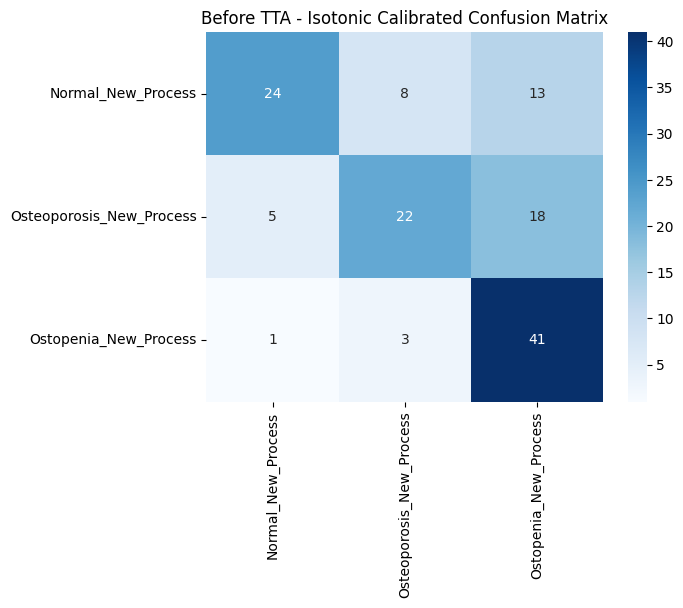


✅ Before TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8296
Avg Set Size: 2.02

✅ After TTA - Isotonic Calibrated RESULTS
AUC: 0.7718
                          precision    recall  f1-score   support

      Normal_New_Process       0.83      0.53      0.65        45
Osteoporosis_New_Process       0.64      0.51      0.57        45
   Ostopenia_New_Process       0.57      0.89      0.70        45

                accuracy                           0.64       135
               macro avg       0.68      0.64      0.64       135
            weighted avg       0.68      0.64      0.64       135

ECE: 0.0731 | MCE: 0.1474


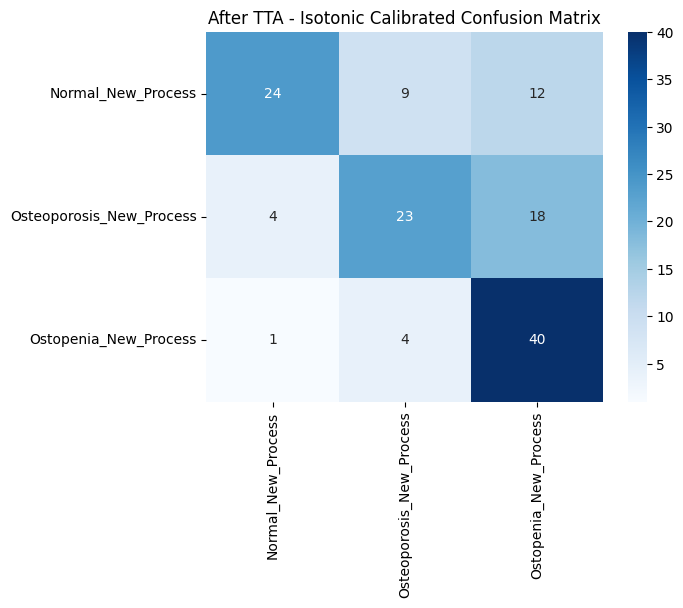


✅ After TTA - Manual Conformal RESULTS
Empirical Coverage: 0.8519
Avg Set Size: 2.04


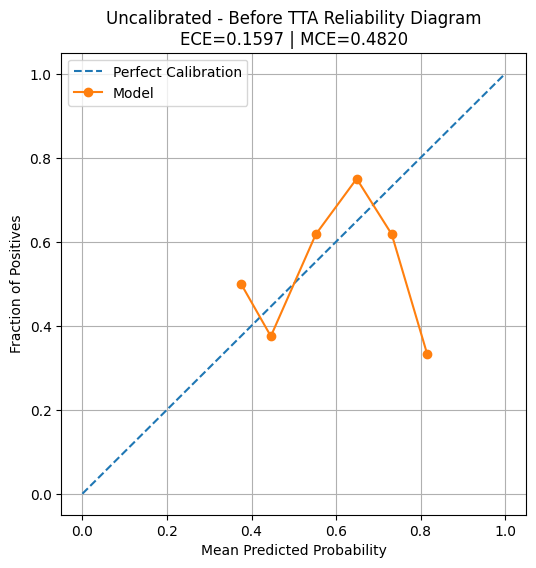

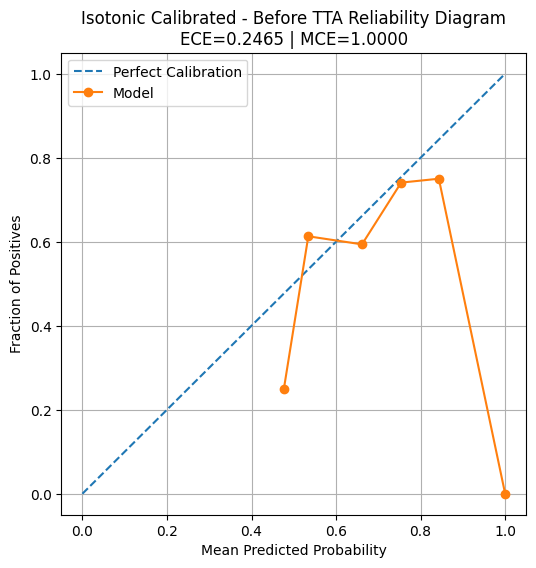

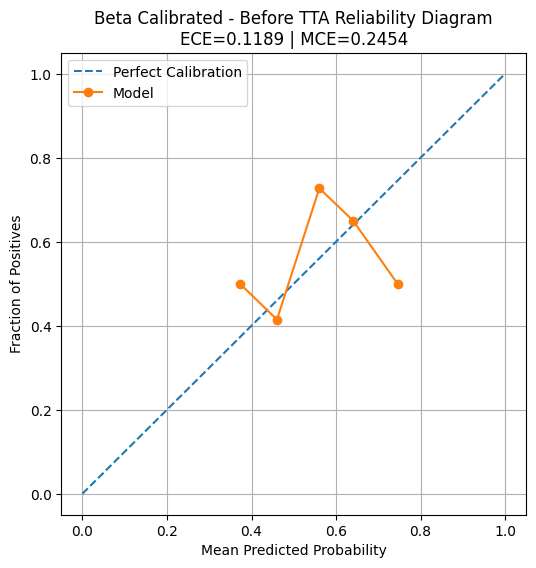

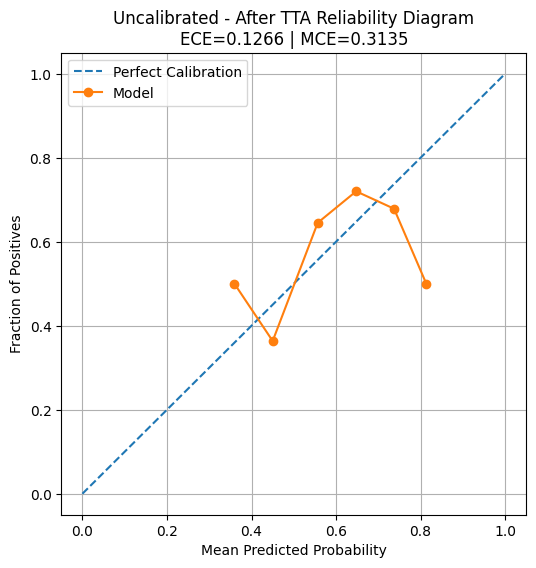

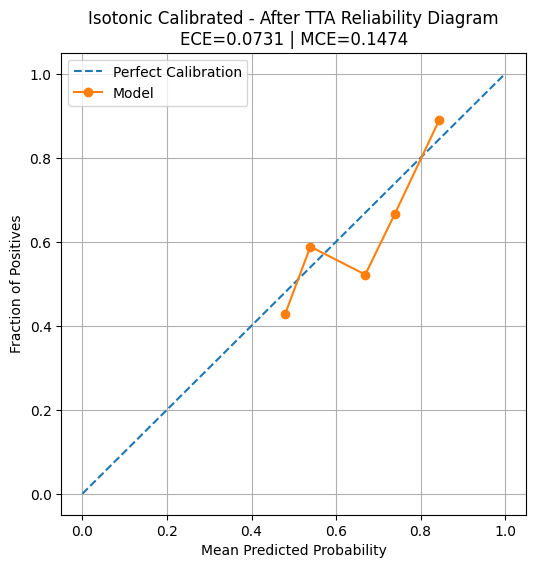

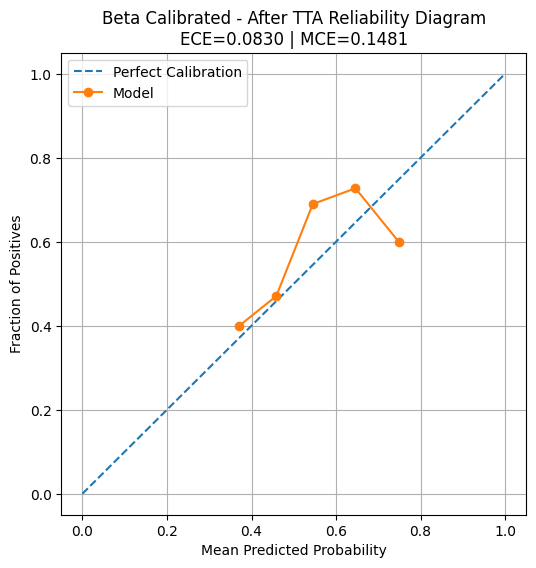


✅ Before TTA - Beta Calibrated RESULTS
AUC: 0.7377
                          precision    recall  f1-score   support

      Normal_New_Process       0.62      0.56      0.59        45
Osteoporosis_New_Process       0.62      0.36      0.45        45
   Ostopenia_New_Process       0.57      0.87      0.68        45

                accuracy                           0.59       135
               macro avg       0.60      0.59      0.57       135
            weighted avg       0.60      0.59      0.57       135

ECE: 0.1189 | MCE: 0.2454


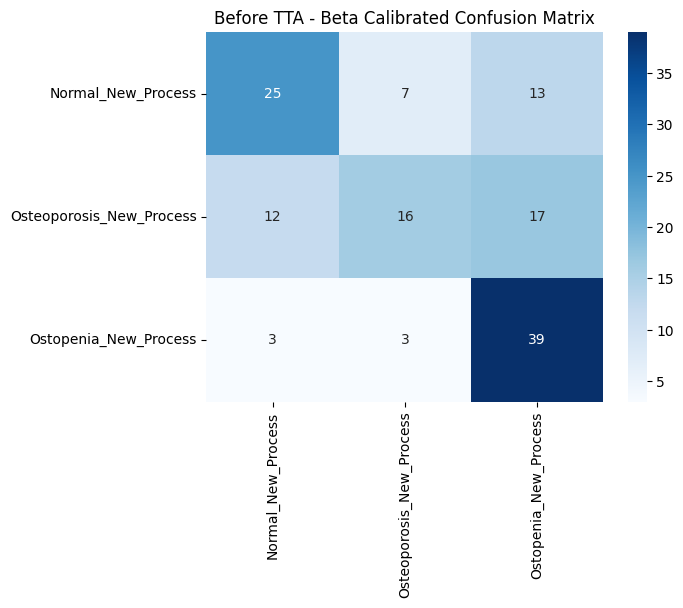


✅ After TTA - Beta Calibrated RESULTS
AUC: 0.7612
                          precision    recall  f1-score   support

      Normal_New_Process       0.67      0.62      0.64        45
Osteoporosis_New_Process       0.65      0.38      0.48        45
   Ostopenia_New_Process       0.60      0.89      0.71        45

                accuracy                           0.63       135
               macro avg       0.64      0.63      0.61       135
            weighted avg       0.64      0.63      0.61       135

ECE: 0.0830 | MCE: 0.1481


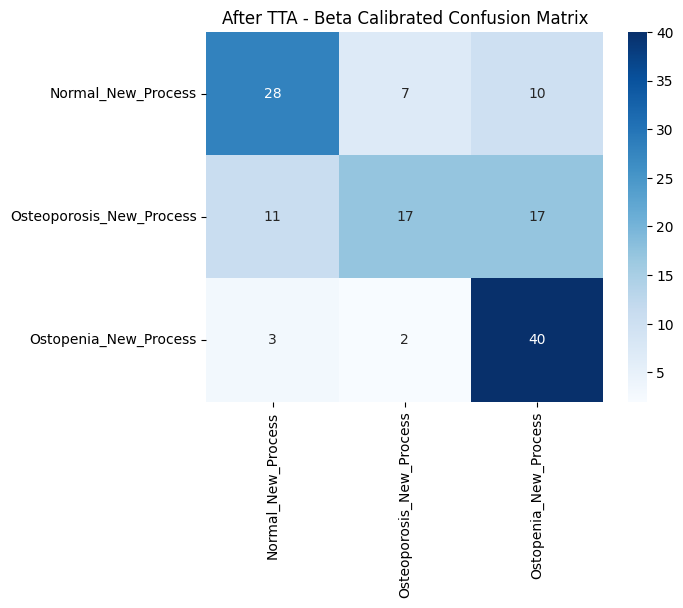

In [1]:
# IMPORTS & SETUP
# --------------------------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification
import cv2

# --------------------------------------------
# CONFIG
# --------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 1
LR_BACKBONE = 5e-6
LR_HEAD = 5e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# --------------------------------------------
# TRANSFORMS & TTA
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
]

# --------------------------------------------
# DATA SPLIT
# --------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# --------------------------------------------
# SEBlock + Swin Definition
# --------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)
    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# --------------------------------------------
# LOAD & WRAP MODEL
# --------------------------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

# ✅ Unfreeze final block
for name, param in model.named_parameters():
    if name.startswith("swin.encoder.layers.3.blocks.1") or name.startswith("swin.encoder.layers.3.blocks.0") or name.startswith("swin.encoder.layers.2.blocks.5") or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --------------------------------------------
# Class Balanced Loss + Optimizer
# --------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# backbone_params = [
#     p for n, p in model.named_parameters()
#     if (
#         n.startswith("swin.encoder.layers.3.blocks.0") or
#         n.startswith("swin.encoder.layers.3.blocks.1") or
#         n.startswith("swin.encoder.layers.2.blocks.17") or
#         n.startswith("swin.encoder.layers.2.blocks.16") or
#         n.startswith("swin.encoder.layers.2.blocks.15") or
#         n.startswith("swin.encoder.layers.2.blocks.14") or
#         n.startswith("swin.encoder.layers.2.blocks.13")
#     ) and p.requires_grad
# ]
# classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

# optimizer = torch.optim.AdamW([
#     {"params": backbone_params, "lr": LR_BACKBONE},
#     {"params": classifier_params, "lr": LR_HEAD}
# ], weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# # --------------------------------------------
# # Training Loop + Validation
# # --------------------------------------------
# best_val_acc = 0.0
# best_model_state = None

# for epoch in range(EPOCHS):
#     model.train()
#     total_loss, total_correct = 0, 0
#     for images, labels in train_loader:
#         images, labels = images.to(DEVICE), labels.to(DEVICE)
#         optimizer.zero_grad()
#         logits = model(images)
#         loss = criterion(logits, labels)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#         total_correct += (logits.argmax(1) == labels).sum().item()
#     train_acc = total_correct / len(train_dataset)

#     model.eval()
#     val_correct, val_loss = 0, 0
#     with torch.no_grad():
#         for images, labels in val_loader:
#             images, labels = images.to(DEVICE), labels.to(DEVICE)
#             logits = model(images)
#             loss = criterion(logits, labels)
#             val_loss += loss.item()
#             val_correct += (logits.argmax(1) == labels).sum().item()
#     val_acc = val_correct / len(val_dataset)
#     scheduler.step()
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_model_state = model.state_dict()

#     print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
# --------------------------------------------
# Progressive Unfreezing CONFIG
# --------------------------------------------
# Define your progressive plan:
progressive_blocks = [
    # Epochs 0–10: only classifier
    [],
    # Epochs 11–30: + last blocks
    ["swin.encoder.layers.3.blocks.0",
     "swin.encoder.layers.3.blocks.1"],
    # Epochs 31–50: + mid layer blocks
    ["swin.encoder.layers.2.blocks.5",
     "swin.encoder.layers.2.blocks.4"],
    # Epochs 51+: + more
    ["swin.encoder.layers.2.blocks.3",
     "swin.encoder.layers.2.blocks.2",
     "swin.encoder.layers.2.blocks.1"],
]

# --------------------------------------------
# Helper: build optimizer & scheduler
# --------------------------------------------
def build_optimizer_and_scheduler(epoch):
    # Decide which blocks to unfreeze for this epoch
    if epoch < 10:
        unfrozen_blocks = []
    elif epoch < 30:
        unfrozen_blocks = progressive_blocks[1]
    elif epoch < 50:
        unfrozen_blocks = progressive_blocks[1] + progressive_blocks[2]
    else:
        unfrozen_blocks = progressive_blocks[1] + progressive_blocks[2] + progressive_blocks[3]

    # Set requires_grad flags
    for name, param in model.named_parameters():
        if any(name.startswith(block) for block in unfrozen_blocks) or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    # Build parameter groups
    backbone_params = [
        p for n, p in model.named_parameters()
        if any(n.startswith(block) for block in unfrozen_blocks) and p.requires_grad
    ]
    classifier_params = [
        p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad
    ]

    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": LR_BACKBONE},
        {"params": classifier_params, "lr": LR_HEAD}
    ], weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    return optimizer, scheduler, unfrozen_blocks

# --------------------------------------------
# Train Loop with Progressive Unfreezing
# --------------------------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):

    # ✅ Rebuild optimizer/scheduler each epoch for new blocks
    optimizer, scheduler, unfrozen_blocks = build_optimizer_and_scheduler(epoch)

    print(f"Epoch [{epoch+1}/{EPOCHS}] — Unfrozen blocks: {unfrozen_blocks if unfrozen_blocks else 'Only Classifier'}")

    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset)

    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    current_lr = scheduler.get_last_lr()
    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f} | LR: {current_lr}")

print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from torchvision.datasets import DatasetFolder
from torchvision.datasets.folder import default_loader



# 1️⃣ Extract penultimate layer embeddings
def get_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE)
            outputs = model.swin(images)
            # Swin's final transformer block output
            feat = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(feat.cpu().numpy())
            labels.extend(target.numpy())
    return np.vstack(embeddings), np.array(labels)

# # Compute class means and covariances
train_embeds, train_labels = get_embeddings(train_dataset)
class_means, class_covs_inv = [], []
for cls in range(NUM_CLASSES):
    cls_feats = train_embeds[train_labels == cls]
    mu = np.mean(cls_feats, axis=0)
    cov = np.cov(cls_feats, rowvar=False) + np.eye(cls_feats.shape[1]) * 1e-6  # Stabilize
    cov_inv = inv(cov)
    class_means.append(mu)
    class_covs_inv.append(cov_inv)

# Compute Mahalanobis distance for test set
test_embeds, test_labels = get_embeddings(test_dataset)
mahal_distances = []
for embed in test_embeds:
    dists = [mahalanobis(embed, mu, cov_inv)
             for mu, cov_inv in zip(class_means, class_covs_inv)]
    mahal_distances.append(min(dists))  # Take min distance over classes

plt.hist(mahal_distances, bins=50)
plt.title("Mahalanobis Distances")
plt.show()

# ------------------------------------------------------------
# ✅ MC Dropout for Epistemic Uncertainty
# ------------------------------------------------------------

def enable_dropout(model):
    """Enable dropout layers during test-time"""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def mc_dropout_predictions(loader, n_samples=30):
    model.eval()
    enable_dropout(model)  # Keep dropout ON
    all_preds = []
    all_labels = []
    for _ in range(n_samples):
        preds = []
        labels = []
        with torch.no_grad():
            for images, batch_labels in loader:
                images = images.to(DEVICE)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)
                preds.append(probs.cpu().numpy())
                labels.extend(batch_labels.numpy())
        all_preds.append(np.vstack(preds))
        all_labels = labels
    all_preds = np.stack(all_preds)  # shape [n_samples, N, C]
    return all_preds, np.array(all_labels)

# Run MC Dropout on your test set
mc_preds, test_labels = mc_dropout_predictions(test_loader, n_samples=30)

# Mean + entropy
mc_mean = mc_preds.mean(axis=0)
mc_std = mc_preds.std(axis=0)
entropy = -np.sum(mc_mean * np.log(mc_mean + 1e-8), axis=1)

print(f"Mean Epistemic Uncertainty (entropy): {entropy.mean():.4f}")

plt.hist(entropy, bins=30)
plt.title("Predictive Entropy (Epistemic Uncertainty)")
plt.show()
def evaluate(probs, test_labels, name):
    """
    probs: shape [N, C] mean probs from MC Dropout or normal softmax
    test_labels: shape [N]
    """
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    # Reliability diagram
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # Reliability plot
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()


# Evaluate using your same function
evaluate(mc_mean, test_labels, "MC Dropout - Epistemic Uncertainty")

from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from scipy.special import logsumexp
import pandas as pd

# ------------------------------------------------------------
# ✅ AFTER TRAINING AND LOADING BEST MODEL
# ------------------------------------------------------------
model.load_state_dict(best_model_state)
model.eval()
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")


# ------------------------------------------------------------
# ✅ 2️⃣ Energy-based OOD Scores
# ------------------------------------------------------------
def compute_energy(logits, T=1.0):
    logits_np = logits.cpu().numpy()
    return -T * logsumexp(logits_np / T, axis=1)

energy_scores = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        e = compute_energy(logits)
        energy_scores.extend(e)

plt.hist(energy_scores, bins=50)
plt.title("Energy-based OOD")
plt.show()
softmax_probs = torch.softmax(logits, dim=1)
max_probs = torch.max(softmax_probs, dim=1).values
print("Mean max softmax prob:", max_probs.mean().item())

print("Logits mean:", logits.mean().item())
print("Logits std:", logits.std().item())

# ------------------------------------------------------------
# ✅ 3️⃣ ODIN Detector
# ------------------------------------------------------------
def odin_score(x, T=5000, eps=0.005):
    x = x.clone().detach().requires_grad_(True).to(DEVICE)
    x.retain_grad()  # ✅ fix for .grad

    logits = model(x) / T
    probs = torch.softmax(logits, dim=1)
    max_probs, _ = torch.max(probs, dim=1)
    loss = -torch.mean(torch.log(max_probs))
    loss.backward()
    grad = torch.sign(x.grad.data)

    x_perturbed = x - eps * grad
    logits_p = model(x_perturbed) / T
    probs_p = torch.softmax(logits_p, dim=1)
    max_probs_p, _ = torch.max(probs_p, dim=1)

    return max_probs_p.detach().cpu().numpy()  # ✅ detach to call numpy()



odin_scores = []
for images, _ in test_loader:
    odin_scores.extend(odin_score(images))

plt.hist(odin_scores, bins=50)
plt.title("ODIN Scores")
plt.show()

# ------------------------------------------------------------
# ✅ 4️⃣ OPTIONAL: VAE Reconstruction for OOD
# ------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim*2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 3*224*224),
            nn.Sigmoid()
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon.view(-1, 3, 224, 224), mu, logvar

vae = VAE().to(DEVICE)
# (Train VAE on train_dataset separately if not done)
vae.eval()
recon_errors = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        recon, _, _ = vae(images)
        loss = torch.mean((images - recon)**2, dim=[1,2,3])
        recon_errors.extend(loss.cpu().numpy())

plt.hist(recon_errors, bins=50)
plt.title("VAE Reconstruction Errors")
plt.show()

# ------------------------------------------------------------
# ✅ COMBINE ALL OOD SCORES
# ------------------------------------------------------------
ood_df = pd.DataFrame({
    "Sample": list(range(len(mahal_distances))),
    "Mahalanobis": mahal_distances,
    "Energy": energy_scores,
    "ODIN": odin_scores,
    "VAE_ReconError": recon_errors
})
print("\n✅ Combined OOD Scores")
print(ood_df.head())

ood_df.to_csv("/kaggle/working/ood_scores.csv", index=False)
print("✅ Saved OOD scores to /kaggle/working/ood_scores.csv")

# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")
# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")
# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels
# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)
# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")
# ---------------------------
# Reliability Diagram Helper
# ---------------------------
def plot_reliability(true_labels, probs, name):
    preds = np.argmax(probs, axis=1)
    true_labels_bin = (preds == true_labels).astype(int)
    probs_max = probs.max(axis=1)

    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------
# BETA Calibrated Probabilities
# ---------------------------
beta_probs_raw = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_raw[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_raw /= beta_probs_raw.sum(axis=1, keepdims=True)

beta_probs_tta = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_tta[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_tta /= beta_probs_tta.sum(axis=1, keepdims=True)

# ---------------------------
# RELIABILITY PLOTS
# ---------------------------
plot_reliability(test_labels, probs_raw, "Uncalibrated - Before TTA")
plot_reliability(test_labels, iso_probs_raw, "Isotonic Calibrated - Before TTA")
plot_reliability(test_labels, beta_probs_raw, "Beta Calibrated - Before TTA")

plot_reliability(test_labels, probs_tta, "Uncalibrated - After TTA")
plot_reliability(test_labels, iso_probs_tta, "Isotonic Calibrated - After TTA")
plot_reliability(test_labels, beta_probs_tta, "Beta Calibrated - After TTA")

# ---------------------------
# Evaluate Beta
# ---------------------------
evaluate(beta_probs_raw, test_labels, "Before TTA - Beta Calibrated")
evaluate(beta_probs_tta, test_labels, "After TTA - Beta Calibrated")






2025-07-09 14:31:51.220530: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752071511.592662      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752071511.709237      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: 630 | Val: 67 | Calib: 68 | Test: 135


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/75] — Unfrozen blocks: Only Classifier
Epoch [1/75] Train Loss: 39.8406 | Val Loss: 4.5639 | Train Acc: 0.5857 | Val Acc: 0.6866 | LR: [4.997807075247147e-06, 0.0004997807075247146]
Epoch [2/75] — Unfrozen blocks: Only Classifier
Epoch [2/75] Train Loss: 35.2521 | Val Loss: 4.2507 | Train Acc: 0.6794 | Val Acc: 0.6866 | LR: [4.997807075247147e-06, 0.0004997807075247146]
Epoch [3/75] — Unfrozen blocks: Only Classifier
Epoch [3/75] Train Loss: 33.6140 | Val Loss: 4.0438 | Train Acc: 0.6825 | Val Acc: 0.7164 | LR: [4.997807075247147e-06, 0.0004997807075247146]
Epoch [4/75] — Unfrozen blocks: Only Classifier
Epoch [4/75] Train Loss: 32.5117 | Val Loss: 3.8670 | Train Acc: 0.6937 | Val Acc: 0.7313 | LR: [4.997807075247147e-06, 0.0004997807075247146]
Epoch [5/75] — Unfrozen blocks: Only Classifier
Epoch [5/75] Train Loss: 32.0363 | Val Loss: 3.8446 | Train Acc: 0.6905 | Val Acc: 0.7612 | LR: [4.997807075247147e-06, 0.0004997807075247146]
Epoch [6/75] — Unfrozen blocks: Only Classifi

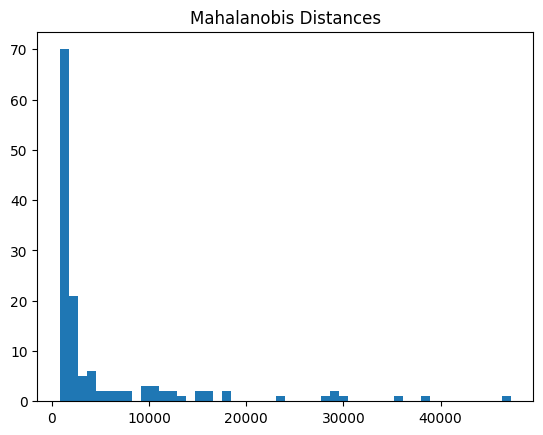

Mean Epistemic Uncertainty (entropy): 0.5309


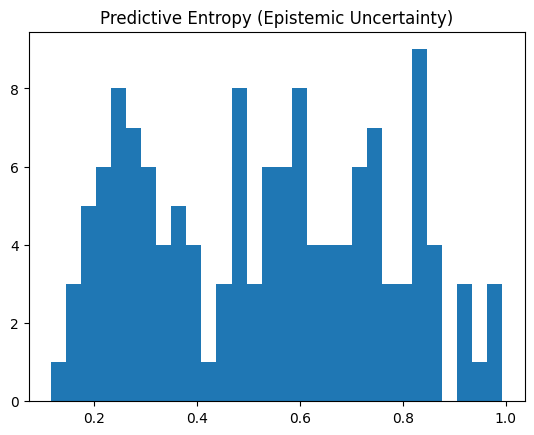


✅ MC Dropout - Epistemic Uncertainty RESULTS
AUC: 0.8878
                          precision    recall  f1-score   support

      Normal_New_Process       0.92      0.78      0.84        45
Osteoporosis_New_Process       0.83      0.67      0.74        45
   Ostopenia_New_Process       0.67      0.91      0.77        45

                accuracy                           0.79       135
               macro avg       0.81      0.79      0.79       135
            weighted avg       0.81      0.79      0.79       135

ECE: 0.1222 | MCE: 0.2301


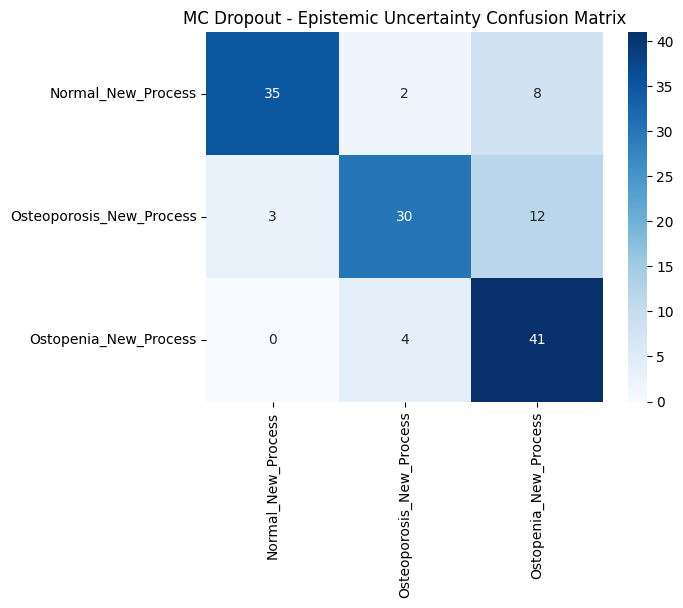

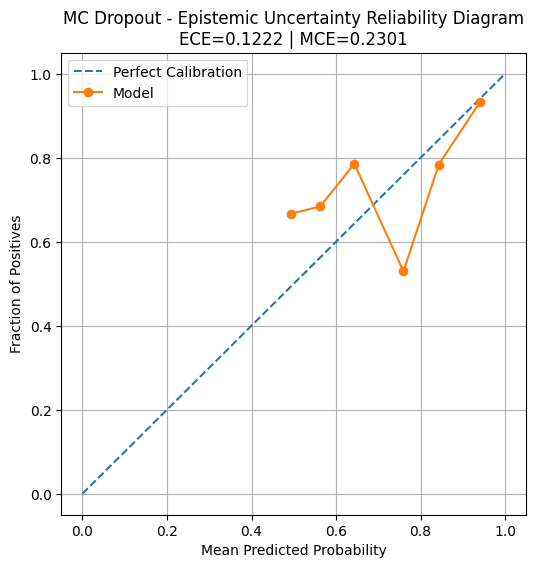

✅ Best Val Accuracy: 0.8209


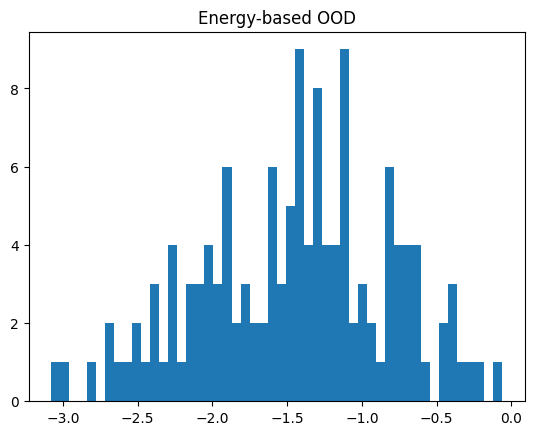

Mean max softmax prob: 0.7517096996307373
Logits mean: -0.6739098429679871
Logits std: 1.5689146518707275


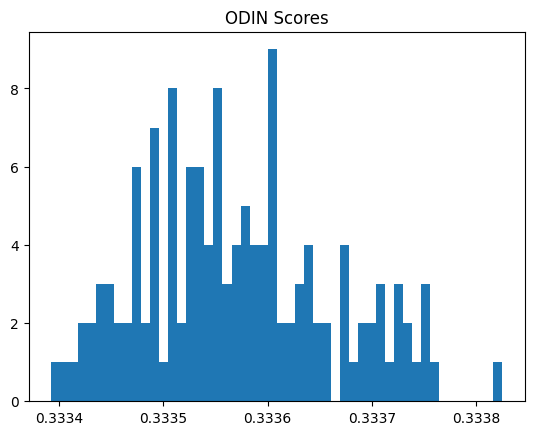

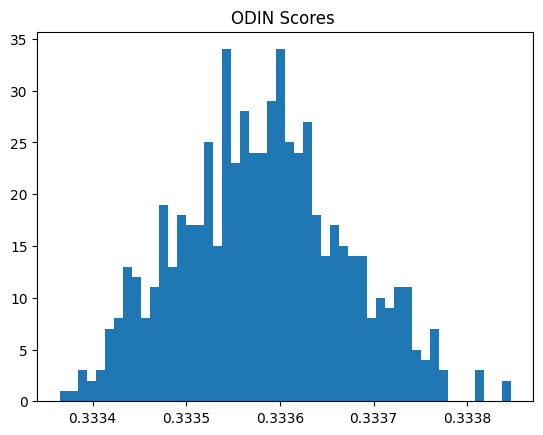

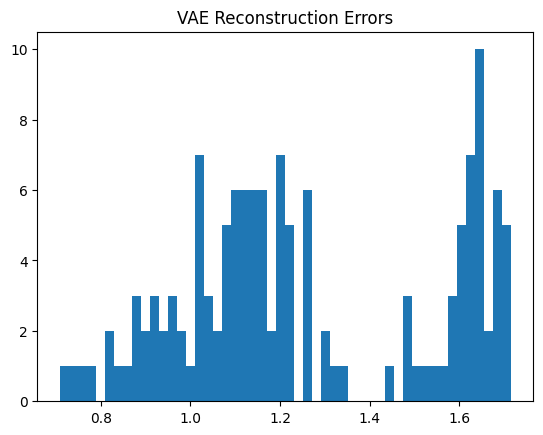


✅ Combined OOD Scores
   Sample  Mahalanobis    Energy      ODIN  VAE_ReconError
0       0  1018.836117 -1.483595  0.333549        1.210893
1       1  2096.261168 -1.301977  0.333655        1.188697
2       2  1907.903492 -0.635058  0.333489        1.701133
3       3  1417.555426 -1.907014  0.333542        1.345202
4       4  1534.447877 -1.417843  0.333655        1.297852
✅ Saved OOD scores to /kaggle/working/ood_scores.csv
Vector Scaling Temperatures: [1.5727893  1.26221347 0.79223825]
Conformal quantile: 0.8339


/tmp/ipykernel_35/365272798.py:629: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()



✅ Before TTA - Isotonic Calibrated RESULTS
AUC: 0.8451
                          precision    recall  f1-score   support

      Normal_New_Process       0.65      0.76      0.70        45
Osteoporosis_New_Process       0.83      0.42      0.56        45
   Ostopenia_New_Process       0.67      0.89      0.76        45

                accuracy                           0.69       135
               macro avg       0.72      0.69      0.67       135
            weighted avg       0.72      0.69      0.67       135

ECE: 0.1539 | MCE: 0.3871


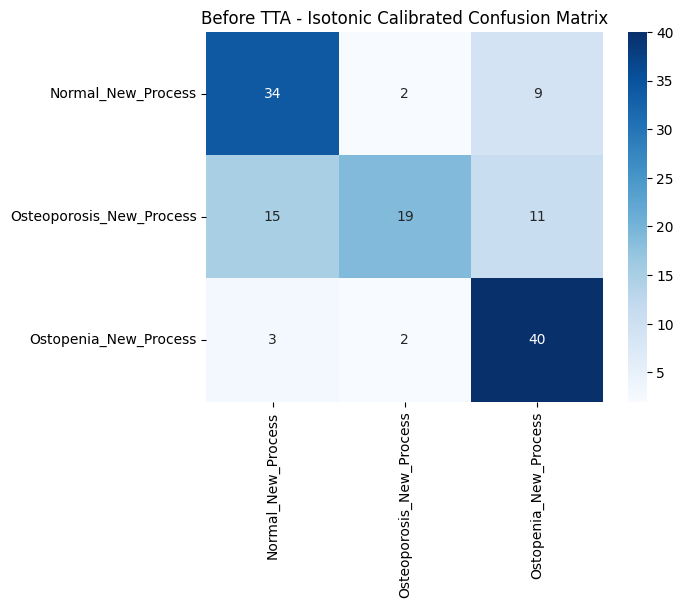


✅ Before TTA - Manual Conformal RESULTS
Empirical Coverage: 0.9037
Avg Set Size: 1.64

✅ After TTA - Isotonic Calibrated RESULTS
AUC: 0.8482
                          precision    recall  f1-score   support

      Normal_New_Process       0.76      0.76      0.76        45
Osteoporosis_New_Process       0.85      0.49      0.62        45
   Ostopenia_New_Process       0.64      0.91      0.75        45

                accuracy                           0.72       135
               macro avg       0.75      0.72      0.71       135
            weighted avg       0.75      0.72      0.71       135

ECE: 0.0681 | MCE: 0.1177


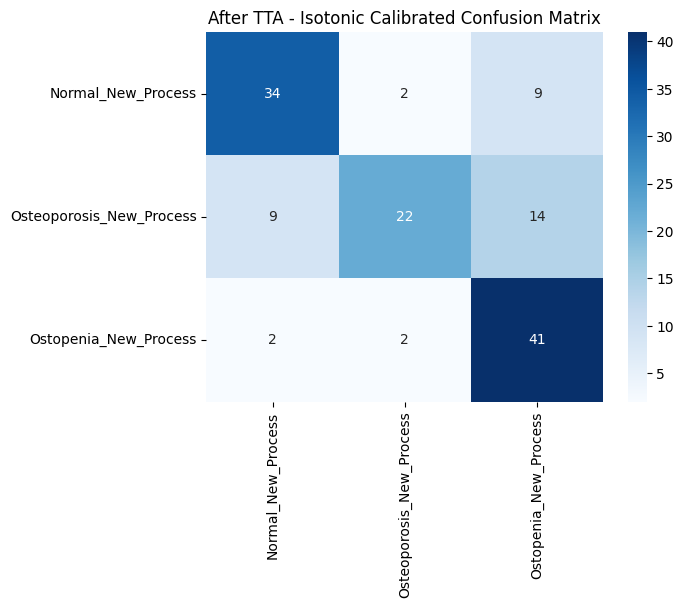


✅ After TTA - Manual Conformal RESULTS
Empirical Coverage: 0.9185
Avg Set Size: 1.69


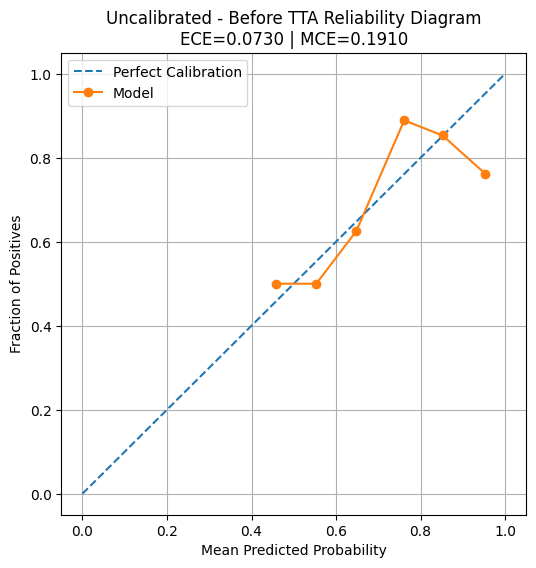

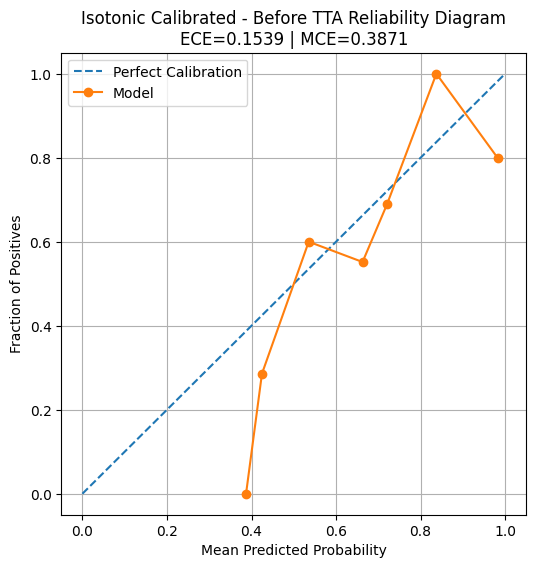

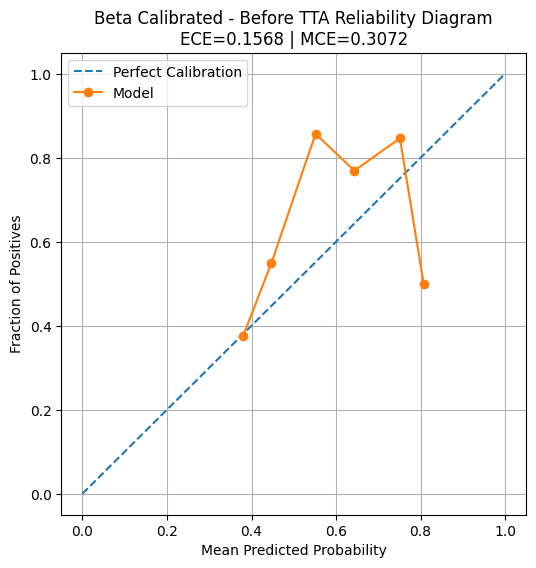

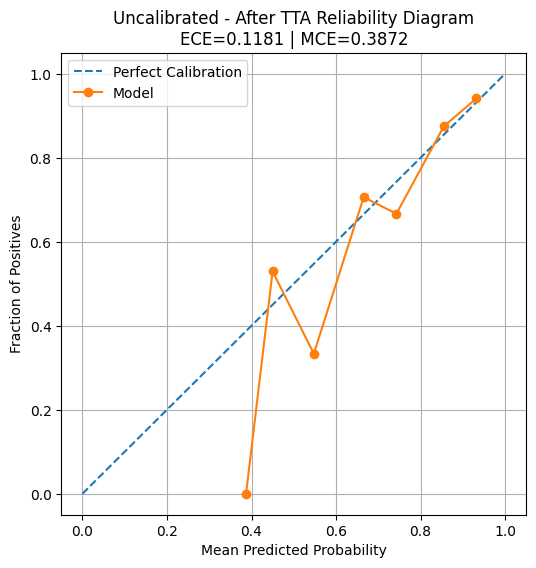

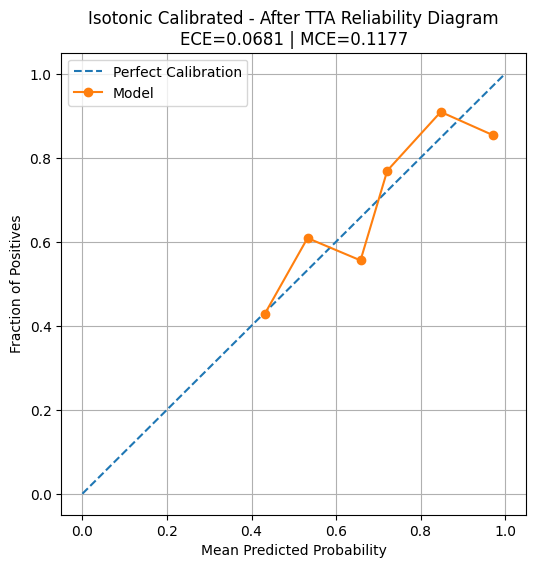

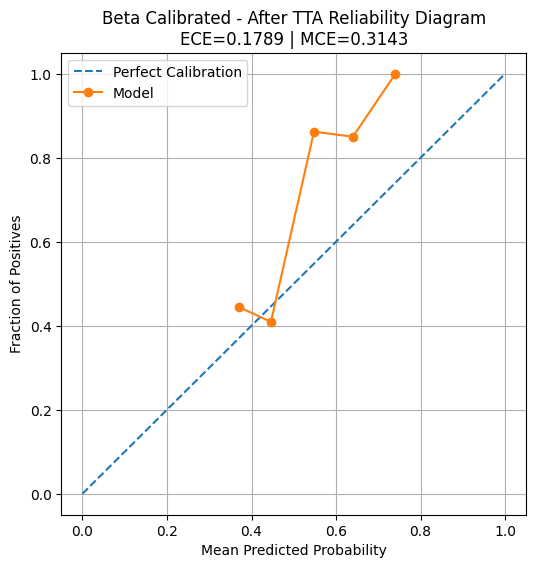


✅ Before TTA - Beta Calibrated RESULTS
AUC: 0.8491
                          precision    recall  f1-score   support

      Normal_New_Process       0.73      0.71      0.72        45
Osteoporosis_New_Process       0.70      0.51      0.59        45
   Ostopenia_New_Process       0.66      0.84      0.74        45

                accuracy                           0.69       135
               macro avg       0.69      0.69      0.68       135
            weighted avg       0.69      0.69      0.68       135

ECE: 0.1568 | MCE: 0.3072


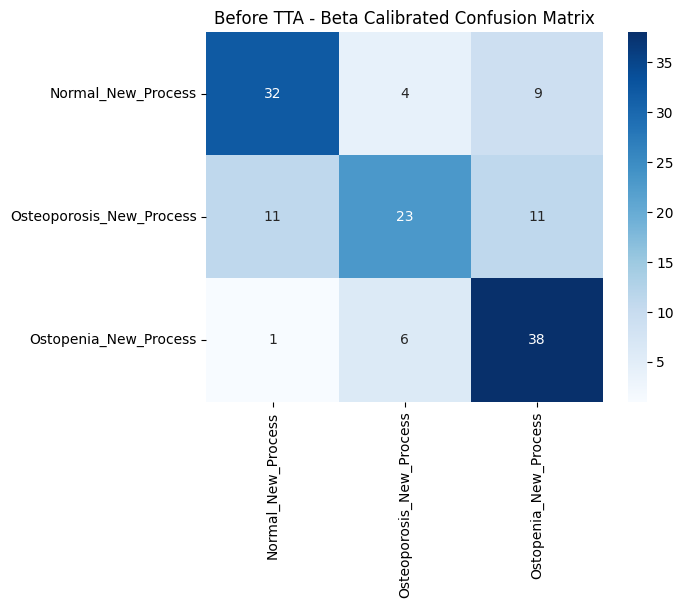


✅ After TTA - Beta Calibrated RESULTS
AUC: 0.8494
                          precision    recall  f1-score   support

      Normal_New_Process       0.79      0.69      0.74        45
Osteoporosis_New_Process       0.60      0.56      0.57        45
   Ostopenia_New_Process       0.61      0.73      0.67        45

                accuracy                           0.66       135
               macro avg       0.67      0.66      0.66       135
            weighted avg       0.67      0.66      0.66       135

ECE: 0.1789 | MCE: 0.3143


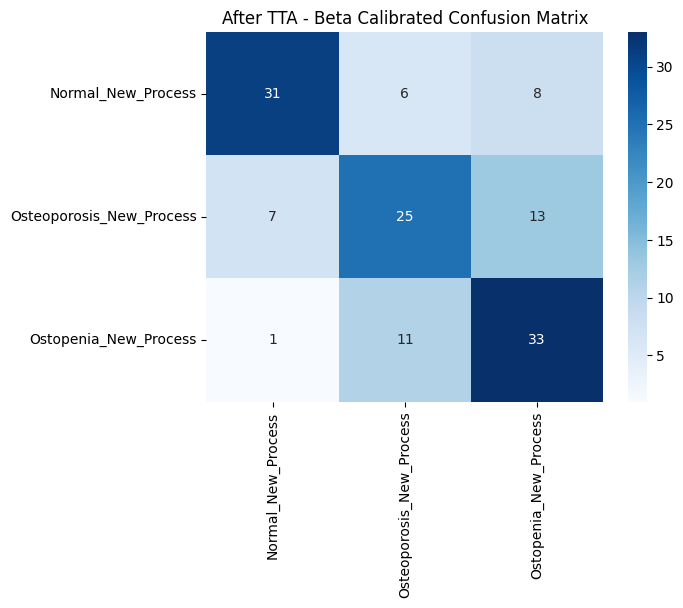

In [1]:
# IMPORTS & SETUP
# --------------------------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve, IsotonicRegression
from scipy.special import betainc
from scipy.optimize import minimize
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoImageProcessor, SwinForImageClassification
import cv2

# --------------------------------------------
# CONFIG
# --------------------------------------------
DATA_DIR = r"/kaggle/input/osteodetect"
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 75
LR_BACKBONE = 5e-6
LR_HEAD = 5e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

# --------------------------------------------
# TRANSFORMS & TTA
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
tta_transforms = [
    test_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
]

# --------------------------------------------
# DATA SPLIT
# --------------------------------------------
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
targets = np.array(full_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=BASE_SEED)
train_idx, val_calib_test_idx = next(sss.split(np.zeros(len(targets)), targets))

sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_calib_idx, test_idx = next(sss_val_test.split(np.zeros(len(val_calib_test_idx)), targets[val_calib_test_idx]))

sss_calib = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=BASE_SEED)
val_idx, calib_idx = next(sss_calib.split(
    np.zeros(len(val_calib_idx)),
    targets[val_calib_test_idx[val_calib_idx]]
))

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[val_idx]])
calib_dataset = Subset(full_dataset, val_calib_test_idx[val_calib_idx[calib_idx]])
test_dataset = Subset(full_dataset, val_calib_test_idx[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Calib: {len(calib_dataset)} | Test: {len(test_dataset)}")

# --------------------------------------------
# SEBlock + Swin Definition
# --------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SwinWithSE(nn.Module):
    def __init__(self, base_model, se_channels=768):
        super(SwinWithSE, self).__init__()
        self.swin = base_model.swin
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = base_model.classifier
        self.se_block = SEBlock(se_channels)
    def forward(self, x):
        outputs = self.swin(x)
        features = outputs.last_hidden_state
        B, N, C = features.shape
        features = features.transpose(1, 2).unsqueeze(-1)
        features = self.se_block(features)
        features = features.squeeze(-1).transpose(1, 2)
        pooled = features.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

# --------------------------------------------
# LOAD & WRAP MODEL
# --------------------------------------------
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
base_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = SwinWithSE(base_model).to(DEVICE)

# ✅ Unfreeze final block
for name, param in model.named_parameters():
    if name.startswith("swin.encoder.layers.3.blocks.1") or name.startswith("swin.encoder.layers.3.blocks.0") or name.startswith("swin.encoder.layers.2.blocks.5") or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --------------------------------------------
# Class Balanced Loss + Optimizer
# --------------------------------------------
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * NUM_CLASSES
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# backbone_params = [
#     p for n, p in model.named_parameters()
#     if (
#         n.startswith("swin.encoder.layers.3.blocks.0") or
#         n.startswith("swin.encoder.layers.3.blocks.1") or
#         n.startswith("swin.encoder.layers.2.blocks.17") or
#         n.startswith("swin.encoder.layers.2.blocks.16") or
#         n.startswith("swin.encoder.layers.2.blocks.15") or
#         n.startswith("swin.encoder.layers.2.blocks.14") or
#         n.startswith("swin.encoder.layers.2.blocks.13")
#     ) and p.requires_grad
# ]
# classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

# optimizer = torch.optim.AdamW([
#     {"params": backbone_params, "lr": LR_BACKBONE},
#     {"params": classifier_params, "lr": LR_HEAD}
# ], weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# # --------------------------------------------
# # Training Loop + Validation
# # --------------------------------------------
# best_val_acc = 0.0
# best_model_state = None

# for epoch in range(EPOCHS):
#     model.train()
#     total_loss, total_correct = 0, 0
#     for images, labels in train_loader:
#         images, labels = images.to(DEVICE), labels.to(DEVICE)
#         optimizer.zero_grad()
#         logits = model(images)
#         loss = criterion(logits, labels)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#         total_correct += (logits.argmax(1) == labels).sum().item()
#     train_acc = total_correct / len(train_dataset)

#     model.eval()
#     val_correct, val_loss = 0, 0
#     with torch.no_grad():
#         for images, labels in val_loader:
#             images, labels = images.to(DEVICE), labels.to(DEVICE)
#             logits = model(images)
#             loss = criterion(logits, labels)
#             val_loss += loss.item()
#             val_correct += (logits.argmax(1) == labels).sum().item()
#     val_acc = val_correct / len(val_dataset)
#     scheduler.step()
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_model_state = model.state_dict()

#     print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
# --------------------------------------------
# Progressive Unfreezing CONFIG
# --------------------------------------------
# Define your progressive plan:
progressive_blocks = [
    # Epochs 0–10: only classifier
    [],
    # Epochs 11–30: + last blocks
    ["swin.encoder.layers.3.blocks.0",
     "swin.encoder.layers.3.blocks.1"],
    # Epochs 31–50: + mid layer blocks
    ["swin.encoder.layers.2.blocks.5",
     "swin.encoder.layers.2.blocks.4"],
    # Epochs 51+: + more
    ["swin.encoder.layers.2.blocks.3",
     "swin.encoder.layers.2.blocks.2",
     "swin.encoder.layers.2.blocks.1"],
]

# --------------------------------------------
# Helper: build optimizer & scheduler
# --------------------------------------------
def build_optimizer_and_scheduler(epoch):
    # Decide which blocks to unfreeze for this epoch
    if epoch < 10:
        unfrozen_blocks = []
    elif epoch < 30:
        unfrozen_blocks = progressive_blocks[1]
    elif epoch < 50:
        unfrozen_blocks = progressive_blocks[1] + progressive_blocks[2]
    else:
        unfrozen_blocks = progressive_blocks[1] + progressive_blocks[2] + progressive_blocks[3]

    # Set requires_grad flags
    for name, param in model.named_parameters():
        if any(name.startswith(block) for block in unfrozen_blocks) or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    # Build parameter groups
    backbone_params = [
        p for n, p in model.named_parameters()
        if any(n.startswith(block) for block in unfrozen_blocks) and p.requires_grad
    ]
    classifier_params = [
        p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad
    ]

    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": LR_BACKBONE},
        {"params": classifier_params, "lr": LR_HEAD}
    ], weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    return optimizer, scheduler, unfrozen_blocks

# --------------------------------------------
# Train Loop with Progressive Unfreezing
# --------------------------------------------
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):

    # ✅ Rebuild optimizer/scheduler each epoch for new blocks
    optimizer, scheduler, unfrozen_blocks = build_optimizer_and_scheduler(epoch)

    print(f"Epoch [{epoch+1}/{EPOCHS}] — Unfrozen blocks: {unfrozen_blocks if unfrozen_blocks else 'Only Classifier'}")

    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset)

    model.eval()
    val_correct, val_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_dataset)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    current_lr = scheduler.get_last_lr()
    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {total_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f} | LR: {current_lr}")

print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")

model.load_state_dict(best_model_state)
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from torchvision.datasets import DatasetFolder
from torchvision.datasets.folder import default_loader



# 1️⃣ Extract penultimate layer embeddings
def get_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE)
            outputs = model.swin(images)
            # Swin's final transformer block output
            feat = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(feat.cpu().numpy())
            labels.extend(target.numpy())
    return np.vstack(embeddings), np.array(labels)

# # Compute class means and covariances
train_embeds, train_labels = get_embeddings(train_dataset)
class_means, class_covs_inv = [], []
for cls in range(NUM_CLASSES):
    cls_feats = train_embeds[train_labels == cls]
    mu = np.mean(cls_feats, axis=0)
    cov = np.cov(cls_feats, rowvar=False) + np.eye(cls_feats.shape[1]) * 1e-6  # Stabilize
    cov_inv = inv(cov)
    class_means.append(mu)
    class_covs_inv.append(cov_inv)

# Compute Mahalanobis distance for test set
test_embeds, test_labels = get_embeddings(test_dataset)
mahal_distances = []
for embed in test_embeds:
    dists = [mahalanobis(embed, mu, cov_inv)
             for mu, cov_inv in zip(class_means, class_covs_inv)]
    mahal_distances.append(min(dists))  # Take min distance over classes

plt.hist(mahal_distances, bins=50)
plt.title("Mahalanobis Distances")
plt.show()

# ------------------------------------------------------------
# ✅ MC Dropout for Epistemic Uncertainty
# ------------------------------------------------------------

def enable_dropout(model):
    """Enable dropout layers during test-time"""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def mc_dropout_predictions(loader, n_samples=30):
    model.eval()
    enable_dropout(model)  # Keep dropout ON
    all_preds = []
    all_labels = []
    for _ in range(n_samples):
        preds = []
        labels = []
        with torch.no_grad():
            for images, batch_labels in loader:
                images = images.to(DEVICE)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)
                preds.append(probs.cpu().numpy())
                labels.extend(batch_labels.numpy())
        all_preds.append(np.vstack(preds))
        all_labels = labels
    all_preds = np.stack(all_preds)  # shape [n_samples, N, C]
    return all_preds, np.array(all_labels)

# Run MC Dropout on your test set
mc_preds, test_labels = mc_dropout_predictions(test_loader, n_samples=30)

# Mean + entropy
mc_mean = mc_preds.mean(axis=0)
mc_std = mc_preds.std(axis=0)
entropy = -np.sum(mc_mean * np.log(mc_mean + 1e-8), axis=1)

print(f"Mean Epistemic Uncertainty (entropy): {entropy.mean():.4f}")

plt.hist(entropy, bins=30)
plt.title("Predictive Entropy (Epistemic Uncertainty)")
plt.show()
def evaluate(probs, test_labels, name):
    """
    probs: shape [N, C] mean probs from MC Dropout or normal softmax
    test_labels: shape [N]
    """
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    # Reliability diagram
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # Reliability plot
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()


# Evaluate using your same function
evaluate(mc_mean, test_labels, "MC Dropout - Epistemic Uncertainty")

from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from scipy.special import logsumexp
import pandas as pd

# ------------------------------------------------------------
# ✅ AFTER TRAINING AND LOADING BEST MODEL
# ------------------------------------------------------------
model.load_state_dict(best_model_state)
model.eval()
print(f"✅ Best Val Accuracy: {best_val_acc:.4f}")


# ------------------------------------------------------------
# ✅ 2️⃣ Energy-based OOD Scores
# ------------------------------------------------------------
def compute_energy(logits, T=1.0):
    logits_np = logits.cpu().numpy()
    return -T * logsumexp(logits_np / T, axis=1)

energy_scores = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        e = compute_energy(logits)
        energy_scores.extend(e)

plt.hist(energy_scores, bins=50)
plt.title("Energy-based OOD")
plt.show()
softmax_probs = torch.softmax(logits, dim=1)
max_probs = torch.max(softmax_probs, dim=1).values
print("Mean max softmax prob:", max_probs.mean().item())

print("Logits mean:", logits.mean().item())
print("Logits std:", logits.std().item())

# ------------------------------------------------------------
# ✅ 3️⃣ ODIN Detector
# ------------------------------------------------------------
def odin_score(x, T=5000, eps=0.005):
    x = x.clone().detach().requires_grad_(True).to(DEVICE)
    x.retain_grad()  # ✅ fix for .grad

    logits = model(x) / T
    probs = torch.softmax(logits, dim=1)
    max_probs, _ = torch.max(probs, dim=1)
    loss = -torch.mean(torch.log(max_probs))
    loss.backward()
    grad = torch.sign(x.grad.data)

    x_perturbed = x - eps * grad
    logits_p = model(x_perturbed) / T
    probs_p = torch.softmax(logits_p, dim=1)
    max_probs_p, _ = torch.max(probs_p, dim=1)

    return max_probs_p.detach().cpu().numpy()  # ✅ detach to call numpy()



odin_scores = []
for images, _ in test_loader:
    odin_scores.extend(odin_score(images))

plt.hist(odin_scores, bins=50)
plt.title("ODIN Scores")
plt.show()

odin_scores_train = []
for images, _ in train_loader:
    odin_scores_train.extend(odin_score(images))

plt.hist(odin_scores_train, bins=50)
plt.title("ODIN Scores ")
plt.show()
# ------------------------------------------------------------
# ✅ 4️⃣ OPTIONAL: VAE Reconstruction for OOD
# ------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim*2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 3*224*224),
            nn.Sigmoid()
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon.view(-1, 3, 224, 224), mu, logvar

vae = VAE().to(DEVICE)
# (Train VAE on train_dataset separately if not done)
vae.eval()
recon_errors = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        recon, _, _ = vae(images)
        loss = torch.mean((images - recon)**2, dim=[1,2,3])
        recon_errors.extend(loss.cpu().numpy())

plt.hist(recon_errors, bins=50)
plt.title("VAE Reconstruction Errors")
plt.show()

# ------------------------------------------------------------
# ✅ COMBINE ALL OOD SCORES
# ------------------------------------------------------------
ood_df = pd.DataFrame({
    "Sample": list(range(len(mahal_distances))),
    "Mahalanobis": mahal_distances,
    "Energy": energy_scores,
    "ODIN": odin_scores,
    "VAE_ReconError": recon_errors
})
print("\n✅ Combined OOD Scores")
print(ood_df.head())

ood_df.to_csv("/kaggle/working/ood_scores.csv", index=False)
print("✅ Saved OOD scores to /kaggle/working/ood_scores.csv")

# ---------------------------
# Vector Scaling Temps
# ---------------------------
def vector_scaling(logits, labels):
    logits = logits.numpy()
    labels = labels.numpy()
    def loss_fn(temps):
        scaled = logits / temps
        exp = np.exp(scaled)
        probs = exp / np.sum(exp, axis=1, keepdims=True)
        loss = -np.mean([np.log(probs[i, labels[i]]) for i in range(len(labels))])
        return loss
    res = minimize(loss_fn, x0=np.ones(NUM_CLASSES), bounds=[(0.5, 5.0)] * NUM_CLASSES)
    return res.x

calib_logits, calib_labels = [], []
with torch.no_grad():
    for images, labels in calib_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        calib_logits.append(outputs.cpu())
        calib_labels.append(labels.cpu())
calib_logits = torch.cat(calib_logits)
calib_labels = torch.cat(calib_labels)
vector_temps = vector_scaling(calib_logits, calib_labels)
print(f"Vector Scaling Temperatures: {vector_temps}")
# ---------------------------
# Calibrate Isotonic & Beta
# ---------------------------
scaled_probs_calib = torch.softmax(torch.tensor(calib_logits) / vector_temps, dim=1).numpy()
iso_models, beta_params = [], []
for i in range(NUM_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(scaled_probs_calib[:, i], np.eye(NUM_CLASSES)[calib_labels][:, i])
    iso_models.append(ir)
    mean = np.mean(scaled_probs_calib[:, i])
    var = np.var(scaled_probs_calib[:, i])
    alpha = ((1 - mean) / var - 1 / mean) * mean ** 2
    beta = alpha * (1 / mean - 1)
    beta_params.append((alpha, beta))

# ---------------------------
# Manual Split Conformal
# ---------------------------
nonconformity = 1 - np.array([scaled_probs_calib[i, y] for i, y in enumerate(calib_labels.numpy())])
quantile = np.quantile(nonconformity, 0.9)
print(f"Conformal quantile: {quantile:.4f}")
# ---------------------------
# Predict helper: with or without TTA
# ---------------------------
def get_predictions(use_tta=True):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            batch_probs = []
            images_cpu = images.cpu()
            transforms_list = tta_transforms if use_tta else [test_transform]
            for tta_transform in transforms_list:
                tta_images = torch.stack([tta_transform(transforms.ToPILImage()(img)) for img in images_cpu])
                tta_images = tta_images.to(DEVICE)
                outputs = model(tta_images)
                scaled = outputs.cpu().numpy() / vector_temps
                exp = np.exp(scaled)
                probs = exp / np.sum(exp, axis=1, keepdims=True)
                batch_probs.append(probs)
            avg_probs = np.mean(batch_probs, axis=0)
            probs_list.append(avg_probs)
            labels_list.append(labels)
    probs = np.vstack(probs_list)
    labels = torch.cat(labels_list).numpy()
    return probs, labels
# ---------------------------
# Final Evaluation Function
# ---------------------------
def evaluate(probs, test_labels, name):
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds, target_names=full_dataset.classes)
    auc = roc_auc_score(np.eye(NUM_CLASSES)[test_labels], probs, multi_class='ovr')
    print(f"\n✅ {name} RESULTS")
    print(f"AUC: {auc:.4f}")
    print(report)
    true_labels_bin = (preds == test_labels).astype(int)
    probs_max = probs.max(axis=1)
    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))
    print(f"ECE: {ece:.4f} | MCE: {mce:.4f}")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

def evaluate_conformal(pred_sets, test_labels, name):
    covered = [test_labels[i] in ps for i, ps in enumerate(pred_sets)]
    coverage = np.mean(covered)
    print(f"\n✅ {name} RESULTS")
    print(f"Empirical Coverage: {coverage:.4f}")
    print(f"Avg Set Size: {np.mean([len(ps) for ps in pred_sets]):.2f}")

# ---------------------------
# Evaluate Before & After TTA
# ---------------------------
probs_raw, test_labels = get_predictions(use_tta=False)
iso_probs_raw = np.column_stack([iso_models[i].predict(probs_raw[:, i]) for i in range(NUM_CLASSES)])
iso_probs_raw /= iso_probs_raw.sum(axis=1, keepdims=True)

evaluate(iso_probs_raw, test_labels, "Before TTA - Isotonic Calibrated")
# Before TTA: compute conformal sets
pred_sets_raw = []
for p in probs_raw:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets_raw.append(included)

evaluate_conformal(pred_sets_raw, test_labels, "Before TTA - Manual Conformal")

# After TTA
probs_tta, test_labels = get_predictions(use_tta=True)
iso_probs_tta = np.column_stack([iso_models[i].predict(probs_tta[:, i]) for i in range(NUM_CLASSES)])
iso_probs_tta /= iso_probs_tta.sum(axis=1, keepdims=True)
# Conformal prediction sets
pred_sets = []
for p in probs_tta:
    included = [i for i in range(NUM_CLASSES) if (1 - p[i]) <= quantile]
    pred_sets.append(included)

evaluate(iso_probs_tta, test_labels, "After TTA - Isotonic Calibrated")
evaluate_conformal(pred_sets, test_labels, "After TTA - Manual Conformal")
# ---------------------------
# Reliability Diagram Helper
# ---------------------------
def plot_reliability(true_labels, probs, name):
    preds = np.argmax(probs, axis=1)
    true_labels_bin = (preds == true_labels).astype(int)
    probs_max = probs.max(axis=1)

    frac_pos, mean_pred = calibration_curve(true_labels_bin, probs_max, n_bins=10)
    ece = np.abs(frac_pos - mean_pred).mean()
    mce = np.max(np.abs(frac_pos - mean_pred))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.title(f"{name} Reliability Diagram\nECE={ece:.4f} | MCE={mce:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------
# BETA Calibrated Probabilities
# ---------------------------
beta_probs_raw = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_raw[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_raw /= beta_probs_raw.sum(axis=1, keepdims=True)

beta_probs_tta = np.column_stack([
    betainc(beta_params[i][0], beta_params[i][1], probs_tta[:, i]) for i in range(NUM_CLASSES)
])
beta_probs_tta /= beta_probs_tta.sum(axis=1, keepdims=True)

# ---------------------------
# RELIABILITY PLOTS
# ---------------------------
plot_reliability(test_labels, probs_raw, "Uncalibrated - Before TTA")
plot_reliability(test_labels, iso_probs_raw, "Isotonic Calibrated - Before TTA")
plot_reliability(test_labels, beta_probs_raw, "Beta Calibrated - Before TTA")

plot_reliability(test_labels, probs_tta, "Uncalibrated - After TTA")
plot_reliability(test_labels, iso_probs_tta, "Isotonic Calibrated - After TTA")
plot_reliability(test_labels, beta_probs_tta, "Beta Calibrated - After TTA")

# ---------------------------
# Evaluate Beta
# ---------------------------
evaluate(beta_probs_raw, test_labels, "Before TTA - Beta Calibrated")
evaluate(beta_probs_tta, test_labels, "After TTA - Beta Calibrated")






In [1]:
# from transformers import SwinForImageClassification

# # Load model
# model = SwinForImageClassification.from_pretrained("microsoft/swin-base-patch4-window7-224")

# # Print all named parameters
# for name, param in model.named_parameters():
#     print(name)


2025-07-09 05:31:35.269453: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752039095.615739      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752039095.717694      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

swin.embeddings.patch_embeddings.projection.weight
swin.embeddings.patch_embeddings.projection.bias
swin.embeddings.norm.weight
swin.embeddings.norm.bias
swin.encoder.layers.0.blocks.0.layernorm_before.weight
swin.encoder.layers.0.blocks.0.layernorm_before.bias
swin.encoder.layers.0.blocks.0.attention.self.relative_position_bias_table
swin.encoder.layers.0.blocks.0.attention.self.query.weight
swin.encoder.layers.0.blocks.0.attention.self.query.bias
swin.encoder.layers.0.blocks.0.attention.self.key.weight
swin.encoder.layers.0.blocks.0.attention.self.key.bias
swin.encoder.layers.0.blocks.0.attention.self.value.weight
swin.encoder.layers.0.blocks.0.attention.self.value.bias
swin.encoder.layers.0.blocks.0.attention.output.dense.weight
swin.encoder.layers.0.blocks.0.attention.output.dense.bias
swin.encoder.layers.0.blocks.0.layernorm_after.weight
swin.encoder.layers.0.blocks.0.layernorm_after.bias
swin.encoder.layers.0.blocks.0.intermediate.dense.weight
swin.encoder.layers.0.blocks.0.inter